# Quantum reservoir computing — many-body dynamics as a machine for time series

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 12 — Quantum reservoir computing*

## 1. Introduction and motivation

A time series arrives one number at a time: $u_1,u_2,u_3,\dots$ — the intensity of a laser, the load on a power grid, the
price of electricity. The generic task is to produce, at every step $k$, an output $\hat y_k$ that approximates some target
$y_k$ which depends on the *whole past* of the input: the next value of the series, a value seen $\tau$ steps ago, or some
nonlinear functional of the history. A machine that does this must have **memory** and must be **nonlinear**.

The textbook answer is a recurrent neural network: a state $\mathbf{x}_k\in\mathbb{R}^n$ updated by
$\mathbf{x}_k=f(W\mathbf{x}_{k-1}+w_{\rm in}u_k)$ and read out by $\hat y_k=\mathbf{w}^{\rm T}\mathbf{x}_k$. Training all of
$W,w_{\rm in},\mathbf{w}$ means propagating gradients backwards through hundreds of time steps; the gradients decay or blow
up exponentially with the number of steps, and the cost function is non-convex. Around 2001 Jaeger, and independently Maass,
Natschläger and Markram, proposed to give up on training the recurrent part entirely: take a **fixed** random dynamical
system, drive it with the input, and train **only the linear readout**. The fixed system — the *reservoir* — has to do two
things: mix past inputs into a high-dimensional nonlinear set of features, and forget its own initial condition. Training
then reduces to linear regression, which is convex and has a closed-form solution.

Nothing in that recipe says the reservoir has to be a neural network. It has to be a driven dynamical system with memory and
nonlinearity — and a many-body quantum system driven by repeated resets of one of its qubits is exactly that. Fujii and
Nakajima made this precise in 2017: the reservoir is a spin network with a fixed Hamiltonian, the input is written into one
spin, the dynamics is unitary evolution for a fixed time $\tau$, and the features are the expectation values
$\langle Z_i\rangle$, $\langle Z_iZ_j\rangle$, ... that one would measure anyway. The Hilbert space of $N$ qubits has
dimension $2^N$ and the space of density matrices has $4^N$ real dimensions, so a handful of qubits carries a very large
internal state; the question this notebook asks — and answers with numbers — is how much of that is actually usable.

**Road map.**

* Section 2 builds classical reservoir computing from the ground up: why training recurrent networks is hard, the
  echo-state construction, the ridge-regression readout derived from scratch, the train/validation/test protocol for time
  series, and the three benchmark tasks (linear memory capacity, NARMA, chaotic laser prediction) with their known bounds.
* Section 3 defines the quantum reservoir: the qubit layout, the input encoding, the reset as a completely positive map
  (derived), the Hamiltonian family, the readout observables and temporal multiplexing, and the proof that the features are
  multilinear functions of trigonometric functions of the past inputs.
* Section 4 implements the protocol twice — as a density tensor and as pure-state trajectories — validates both against a
  dense-matrix reference, and measures the $1/\sqrt{M}$ statistical error.
* Section 5 measures the echo-state property directly: two different initial states, the same input, the trace distance
  between them as a function of step.
* Section 6 measures the linear memory capacity against the number of readout features, the evolution time, the number of
  qubits, the disorder strength and the number of virtual nodes.
* Sections 7 and 8 run the NARMA and Santa Fe laser tasks and compare the quantum reservoir with two classical baselines
  trained in exactly the same way.
* Section 9 replaces exact expectation values by estimates from $M$ measurement repetitions and asks what that costs.
* Section 10 lets the reservoir decohere during its evolution and measures whether mild dissipation helps.
* Section 11 collects the cost model and the timings.

### What you will learn

**Physics**

* how a driven open many-body system acts as a nonlinear filter with fading memory, and where that memory physically lives;
* why an erasure (a qubit reset) — not the unitary dynamics — is what makes the map forget its initial condition;
* what a measurement readout of a reservoir really costs, and how decoherence changes the trade-off between memory and
  nonlinearity.

**Numerical methods**

* ridge regression from the normal equations, its singular-value form, and why regularisation is not optional here;
* memory capacity and its rigorous upper bound by the number of linearly independent state variables;
* statistics over random reservoirs (medians and bands, never a single run), train/validation/test splitting for
  correlated data, and honest baselines.

**Implementation practice**

* the entire drive over a time series as one `lax.scan` whose carry is the quantum state and whose outputs are the
  features, compiled once with `jax.jit`;
* `jax.vmap` over disorder realisations of the Hamiltonian and over quantum trajectories;
* a channel (partial trace plus re-preparation) implemented as two Kraus operators and validated against an independent
  dense-matrix computation.

### Prerequisites
* [Chapter 3 / 07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb): density tensors, partial trace, Kraus channels;
* [Chapter 3 / 08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb): Born rule, collapse, reset, shot noise;
* [Chapter 5 / 12 — TEBD](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb): Trotter–Suzuki gate sequences;
* [Chapter 6 / 16 — Lindblad master equation](../ch06_open_quantum_systems/16_lindblad_master_equation.ipynb) and
  [Chapter 6 / 17 — quantum trajectories](../ch06_open_quantum_systems/17_monte_carlo_wave_function.ipynb): dissipative dynamics, density tensor versus trajectories;
* [Chapter 1 / 01 — JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, `lax.scan`, PRNG keys.

Units and conventions as before: $\hbar=1$, $\vert 0\rangle$ is the $+1$ eigenstate of $Z$, Hamiltonians are written with
Pauli matrices (not spin-$1/2$ operators), qubit $q$ is tensor axis $q$.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP  (auto-generated from quantum_engine.py -- derived step by step in Part 0)
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
SM = jnp.array([[0, 1], [0, 0]], dtype=CDTYPE)  # sigma^- = |0><1| : lowers |1> -> |0>
P0 = jnp.array([[1, 0], [0, 0]], dtype=CDTYPE)  # projector |0><0|
P1 = jnp.array([[0, 0], [0, 1]], dtype=CDTYPE)  # projector |1><1|
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)
def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "Ab,abc->aAc"          A = new (output) index of qubit 1
        N=4, q=(1,3)    :  "ABbd,abcd->aAcB"      A,B = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter; U carries (new letters)+(old letters of the targets); the output is psi's
    labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; m = Kraus index, summed!)
        "mAa, mBc, abcd -> AbBd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def rdm_dm(rho, keep):
    """Partial trace of a density TENSOR (rank 2N), keeping the qubits `keep`.

    MATH      rho_A[a,a'] = sum_b rho[a,b ; a',b]
    EINSUM    N=2, keep=(0,):  "abAb->aA"   -- the letter b is REPEATED inside one operand and absent
              from the output: that is a trace over that pair of axes.
    """
    keep = tuple(int(q) for q in keep)
    N = rho.ndim // 2
    ket = list(_LETTERS[:N])
    bra = [(_LETTERS[N + q] if q in keep else ket[q]) for q in range(N)]
    sub = f"{''.join(ket)}{''.join(bra)}->{''.join(ket[q] for q in keep)}{''.join(bra[q] for q in keep)}"
    return jnp.einsum(sub, rho).reshape(2 ** len(keep), 2 ** len(keep))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def purity(rho_mat):
    """Tr(rho^2): 1 for pure states, 1/d for the maximally mixed state in dimension d."""
    return jnp.real(jnp.trace(rho_mat @ rho_mat))

def _sqrtm_psd(A):
    """Square root of a positive semi-definite matrix via eigendecomposition: V sqrt(w) V^dag."""
    w, v = jnp.linalg.eigh(A)
    return (v * jnp.sqrt(jnp.clip(w, 0, None))) @ v.conj().T

def trace_distance(rho, sigma):
    """D = (1/2)||rho - sigma||_1 = (1/2) sum_i |eigenvalue_i(rho - sigma)|  (Hermitian difference)."""
    return 0.5 * jnp.sum(jnp.abs(jnp.linalg.eigvalsh(rho - sigma)))


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def measure_qubit(key, psi, q, basis="Z"):
    """Projective measurement of qubit q in the eigenbasis of X, Y or Z.  Returns (outcome, post-state).

    MATH   Born rule      p(0) = <psi|P0_q|psi> = (rho_q)[0,0]          (only the 1-qubit RDM is needed)
           collapse       |psi> -> P_m|psi> / sqrt(p(m))
           other bases    measuring P = U^dag Z U  ==  rotate with U, measure Z, rotate back with U^dag
                          (X: U = H;   Y: U = H S^dag).
    outcome 0 <-> eigenvalue +1,   outcome 1 <-> eigenvalue -1.
    JAX    no Python `if` on random data: `jnp.where` selects the projector, so the function is
           jit/vmap-able (vmap over keys = many independent shots).
    """
    U = _BASIS_ROT[basis]
    psi = apply_gate(psi, U, [q])
    p0 = jnp.real(rdm(psi, [q])[0, 0])
    outcome = (jax.random.uniform(key) >= p0).astype(jnp.int32)
    proj = jnp.where(outcome == 0, P0, P1)
    psi = apply_gate(psi, proj, [q])
    psi = psi / jnp.linalg.norm(psi)
    return outcome, apply_gate(psi, U.conj().T, [q])

def reset_qubit(key, psi, q):
    """Active reset: measure qubit q in Z and apply X if the outcome was 1 -> qubit ends in |0>,
    disentangled from the rest (used in teleportation-like protocols, autoencoders, reservoirs)."""
    outcome, psi = measure_qubit(key, psi, q)
    return apply_gate(psi, jnp.where(outcome == 1, X, I2), [q])

def sample_bitstrings(key, psi, shots, bases=None):
    """Sample `shots` outcomes of measuring ALL qubits (no collapse bookkeeping needed).

    MATH   p(s) = |psi[s]|^2 ; optional per-qubit bases string like 'XZY' rotates first.
    IMPLEMENTATION   `jax.random.categorical` draws flat indices from log-probabilities; the bits are
    unpacked with shifts:  s_q = (i >> (N-1-q)) & 1   (qubit 0 = most significant bit).
    Returns an int array of shape (shots, N).
    """
    N = psi.ndim
    if bases is not None:
        for q, b in enumerate(bases):
            psi = apply_gate(psi, _BASIS_ROT[b], [q])
    logp = jnp.log(jnp.clip(jnp.abs(psi.reshape(-1)) ** 2, 1e-300, None))
    idx = jax.random.categorical(key, logp, shape=(shots,))
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_from_jump(L, gamma_dt):
    """Kraus pair generated by a Lindblad jump operator L acting for a short time dt (rate gamma):
        K1 = sqrt(gamma dt) L                      'a jump happened'
        K0 = sqrt(1 - gamma dt L^dag L)            'no jump'  (~ exp(-gamma dt L^dag L / 2))
    Completeness K0^dag K0 + K1^dag K1 = 1 holds EXACTLY, so the map is trace preserving for any dt;
    it reproduces the Lindblad dissipator up to O(dt^2)."""
    L = jnp.asarray(L, dtype=CDTYPE)
    K0 = _sqrtm_psd(jnp.eye(L.shape[0], dtype=CDTYPE) - gamma_dt * (L.conj().T @ L))
    return jnp.stack([K0, jnp.sqrt(gamma_dt) * L])


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def _expm_herm(h, tau):
    """exp(-i tau h) for a SMALL Hermitian matrix: h = V w V^dag  =>  V exp(-i tau w) V^dag."""
    w, v = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (v * jnp.exp(-1j * tau * w)) @ v.conj().T

def tebd_gates(terms, dt, order=2):
    """Gate sequence of ONE Trotter-Suzuki (TEBD) step for H = sum_k h_k.

    MATH   exp(-i H dt) cannot be split exactly because [h_k, h_l] != 0, but (BCH formula):
        order 1:  prod_k e^{-i h_k dt}                                       local error O(dt^2), global O(dt)
        order 2:  prod_k e^{-i h_k dt/2} * prod_k(reversed) e^{-i h_k dt/2}  local O(dt^3), global O(dt^2)
        order 4:  S2(s dt)^2 S2((1-4s) dt) S2(s dt)^2,  s = 1/(4 - 4^{1/3})  (Suzuki)   global O(dt^4)
    Each factor is a 2x2 or 4x4 unitary -> applied by einsum; this is TEBD on a full state vector.
    Every order is exactly unitary: the norm is conserved to machine precision; the ERROR is in the phase
    /direction of the state, and it is controlled by dt.
    """
    if order == 1:
        return [(q, _expm_herm(h, dt)) for q, h in terms]
    if order == 2:
        half = [(q, _expm_herm(h, dt / 2)) for q, h in terms]
        return half + half[::-1]
    if order == 4:
        s = 1.0 / (4.0 - 4.0 ** (1.0 / 3.0))
        seq = []
        for w in (s, s, 1 - 4 * s, s, s):
            seq += tebd_gates(terms, w * dt, order=2)
        return seq
    raise ValueError("order must be 1, 2 or 4")

def apply_gates(psi, gates):
    """Apply a list [(qubits, U), ...] in order -- a quantum circuit is a Python loop over einsums.
    Under `jax.jit` the loop is unrolled at trace time and XLA fuses it into one program."""
    for qubits, U in gates:
        psi = apply_gate(psi, U, qubits)
    return psi

def apply_gates_dm(rho, gates):
    """Same circuit on a density tensor (U on kets, U^* on bras)."""
    for qubits, U in gates:
        rho = apply_gate_dm(rho, U, qubits)
    return rho

def exact_evolve(psi, terms, t):
    """Dense reference for small N: full diagonalisation H = V w V^dag, |psi(t)> = V e^{-i w t} V^dag |psi>.
    O(8^N) time, O(4^N) memory -- the wall that matrix-free methods avoid; used only to validate them."""
    N = psi.ndim
    w, v = jnp.linalg.eigh(dense_hamiltonian(terms, N))
    return ((v * jnp.exp(-1j * t * w)) @ (v.conj().T @ psi.reshape(-1))).reshape((2,) * N)


## 2. Reservoir computing

### 2.1 The learning problem

We are given an input sequence $u_1,\dots,u_T$ (real numbers) and a target sequence $y_1,\dots,y_T$. We look for a map that
produces $\hat y_k$ from the inputs up to time $k$ and minimises the mean-square error. Three examples, all used below:

| task | target $y_k$ | what it tests |
|---|---|---|
| delay line | $u_{k-\tau}$ | linear memory of depth $\tau$ |
| NARMA | output of a nonlinear recursion driven by $u$ | memory *and* nonlinearity |
| prediction | $u_{k+h}$ | everything, on real data |

A machine that solves any of them needs a **state** that summarises the past. Write it as a recurrence

$$ \mathbf{x}_k = f(\mathbf{x}_{k-1}, u_k), \qquad \hat y_k = \mathbf{w}^{\rm T}\mathbf{x}_k + b . \tag{1}$$

### 2.2 Why the recurrent part is not trained

Suppose we try to optimise the parameters of $f$ by gradient descent on $\sum_k(y_k-\hat y_k)^2$. The gradient of the error
at step $k$ with respect to a parameter that acted at step $k-n$ contains the product of $n$ Jacobians,

$$ \frac{\partial \mathbf{x}_k}{\partial \mathbf{x}_{k-n}} = \prod_{j=0}^{n-1}\frac{\partial f}{\partial \mathbf{x}}\Big\vert_{k-j} . $$

A product of $n$ matrices either shrinks or grows exponentially in $n$ unless its factors are extremely finely tuned: the
*vanishing and exploding gradient* problem. Add that the cost is non-convex in the recurrent parameters and that
backpropagation through time has to store the whole trajectory, and the practical conclusion of the early 2000s becomes
understandable: **do not train $f$ at all**. Choose it at random, keep it fixed, and train only $\mathbf{w}$ and $b$, which
enter Eq. (1) *linearly*. The error is then a quadratic function of the trainable parameters: one convex problem with a
closed-form solution. This is the *echo-state network* of Jaeger and the *liquid-state machine* of Maass, Natschläger and
Markram; the review by Lukoševičius and Jaeger collects the practice that grew around them.

### 2.3 The two properties a reservoir must have

**(a) Echo-state property (fading memory).** For a fixed input sequence, the state must forget its initial condition:
two runs started in different states $\mathbf{x}_0\neq\mathbf{x}_0'$ and driven by the *same* input must converge,

$$ \lVert \mathbf{x}_k-\mathbf{x}_k'\rVert \xrightarrow[k\to\infty]{} 0 . $$

Without it the features depend on an arbitrary initial condition and nothing learned on a training block transfers to a test
block. For the standard sigmoid network $\mathbf{x}_k=\tanh(W\mathbf{x}_{k-1}+w_{\rm in}u_k)$ a *sufficient* condition is
that $W$ be a contraction, $\sigma_{\max}(W)<1$; the widely used recipe "spectral radius $\rho(W)<1$" is a practical
heuristic and is **not** sufficient in general, as Yildiz, Jaeger and Kiebel showed with explicit counterexamples.

**(b) Separation and nonlinearity.** Different input histories must give different states (otherwise no readout can tell
them apart), and the map from inputs to features must be nonlinear — a linear reservoir with a linear readout is just a
linear filter of the input and can never produce $u_k^2$ or $u_ku_{k-1}$.

The two requirements pull in opposite directions: strong mixing separates histories but destroys memory; weak coupling
preserves memory but leaves the features nearly linear in the input. Every reservoir has a knob that interpolates between
the two, and finding its useful range is the main experimental work. For our quantum reservoir the knob is the evolution
time $\tau$ per input step.

### 2.4 The readout: ridge regression, derived

Collect the features of the $n$ training steps in a matrix $X\in\mathbb{R}^{n\times p}$ (row $k$ = the $p$ features at step
$k$) and the targets in $\mathbf{y}\in\mathbb{R}^{n}$. With weights $\mathbf{w}\in\mathbb{R}^p$ and bias $b$ we minimise

$$ E(\mathbf{w},b) = \sum_{k=1}^{n}\big(y_k-\mathbf{x}_k^{\rm T}\mathbf{w}-b\big)^2 + \alpha\lVert\mathbf{w}\rVert^2 . \tag{2}$$

The bias is *not* penalised: it only shifts the output and has no reason to be small. Setting $\partial E/\partial b=0$,

$$ -2\sum_k\big(y_k-\mathbf{x}_k^{\rm T}\mathbf{w}-b\big)=0 \qquad\Longrightarrow\qquad b=\bar y-\bar{\mathbf{x}}^{\rm T}\mathbf{w}, $$

with $\bar y$ and $\bar{\mathbf{x}}$ the training means. Substituting this back makes the problem one of *centred*
variables, so from now on we assume that the columns of $X$ and the target have been centred (in the code we also divide
each column by its training standard deviation, which puts all features on the same footing and makes one value of $\alpha$
meaningful for all of them). Differentiating Eq. (2) with respect to $\mathbf{w}$,

$$ \frac{\partial E}{\partial\mathbf{w}} = -2X^{\rm T}(\mathbf{y}-X\mathbf{w})+2\alpha\mathbf{w} = 0 , $$

gives the **normal equations** and their closed-form solution

$$ \big(X^{\rm T}X+\alpha\mathbb{1}\big)\,\mathbf{w} = X^{\rm T}\mathbf{y}, \qquad \mathbf{w}=\big(X^{\rm T}X+\alpha\mathbb{1}\big)^{-1}X^{\rm T}\mathbf{y} . \tag{3}$$

Why regularise? Insert the singular-value decomposition $X=U\Sigma V^{\rm T}$ with singular values $\sigma_i$:

$$ \mathbf{w} = \sum_i \frac{\sigma_i}{\sigma_i^2+\alpha}\,\big(\mathbf{u}_i^{\rm T}\mathbf{y}\big)\,\mathbf{v}_i . \tag{4}$$

For $\alpha=0$ a direction with a tiny $\sigma_i$ contributes with weight $1/\sigma_i$: the fit amplifies exactly those
combinations of features that the data barely determines, and any noise in $\mathbf{y}$ or in the features is amplified with
it. The factor $\sigma_i^2/(\sigma_i^2+\alpha)$ in the fitted values shrinks those directions smoothly to zero. How much
this matters is an empirical question — it depends on how collinear the features are and how noisy the data is — and
Section 9 measures it for this machine instead of assuming it.

### 2.5 Protocol for time series: washout, contiguous splits, validation

Three rules, all of which we follow everywhere below.

1. **Washout.** The first $K_{\rm wo}$ steps are discarded from every fit: they still depend on the initial state of the
   reservoir. With the echo-state property the dependence decays; the washout is where it decays.
2. **Contiguous splits.** Training, validation and test blocks are *consecutive* stretches of the series, never a random
   shuffle: neighbouring samples of a time series are strongly correlated, and a random split leaks the answer from the
   training set into the test set.
3. **Validation for hyper-parameters.** $\alpha$ is chosen on a validation block and the error is then reported on a
   *third*, untouched test block. Reporting the best test error over a grid of $\alpha$ is a silent way of fitting the test
   set.

We use $60\,\%$ training, $20\,\%$ validation, $20\,\%$ test after the washout.

### 2.6 The benchmark tasks and what is known about them

**Linear memory capacity.** For the delay task $y_k=u_{k-\tau}$ with an i.i.d. input define

$$ C(\tau) = \frac{\operatorname{cov}^2\!\big(\hat y_k, u_{k-\tau}\big)}{\operatorname{var}(\hat y_k)\operatorname{var}(u_{k-\tau})}\in[0,1],
   \qquad \mathrm{MC}=\sum_{\tau\ge1}C(\tau), \tag{5}$$

the squared Pearson correlation between the optimally trained readout and the delayed input. $C(\tau)=1$ means the reservoir
reproduces $u_{k-\tau}$ exactly. Jaeger proved (GMD Report 152, Proposition 2) that for an i.i.d. input and a *linear*
readout the total capacity of a network with $n$ state variables obeys

$$ \mathrm{MC}\le n . $$

Dambre, Verstraeten, Schrauwen and Massar later generalised the statement to arbitrary nonlinear target functionals: the sum
of capacities over any orthogonal family of functionals of the input is bounded by the number of **linearly independent**
state variables, with equality when the system has fading memory and the state variables are linearly independent. For us
the "state variables" are the readout features, so the bound reads $\mathrm{MC}\le p$ with $p$ the number of features. Two
caveats that Section 6 will make quantitative: the bound counts *linearly independent* variables, and our features are far
from independent; and both statements assume an i.i.d. input, which the laser series of Section 8 is emphatically not.

**NARMA.** A nonlinear auto-regressive moving-average system driven by $u_k\sim\mathcal{U}[0,0.5]$. We use the second-order
system of Atiya and Parlos,

$$ y_{k+1} = 0.4\,y_k + 0.4\,y_k y_{k-1} + 0.6\,u_k^3 + 0.1, \tag{6}$$

and the $n$-th order form that the reservoir-computing literature quotes as NARMA-$n$ (introduced for $n=10$ by Atiya and
Parlos and written in this general form by Rodan and Tiňo),

$$ y_{k+1} = 0.3\,y_k + 0.05\,y_k\sum_{i=0}^{n-1}y_{k-i} + 1.5\,u_{k-n+1}u_k + 0.1 . \tag{7}$$

The target depends on its own past, so a good score needs memory of order $n$ steps *and* products of inputs.

**Santa Fe laser data.** Data set A of the Santa Fe time-series competition: the intensity of a far-infrared
$^{14}$NH$_3$ laser in a chaotic regime, recorded by U. Hübner with N. B. Abraham and C. O. Weiss and contributed to the
competition edited by Weigend and Gershenfeld. The series is famous for its intermittent collapses, which is exactly what a
purely linear model cannot predict.

> **Numerical practice.** Quote errors as the *normalised* mean-square error
> $\mathrm{NMSE}=\langle(\hat y-y)^2\rangle/\operatorname{var}(y)$ on the test block. $\mathrm{NMSE}=1$ is what the constant
> predictor $\hat y=\bar y$ achieves, so any number above $1$ means the model is worse than useless, and the value is
> independent of the units of $y$.

In [3]:
# ==============================================================================
# READOUT: ridge regression with an unpenalised bias, and the evaluation protocol
# ==============================================================================
def normal_equations(X, y):
    """Gram matrix and right-hand side of Eq. (3) for the design matrix augmented by a bias column.

    MATH  A = [X, 1];  returns (A^T A, A^T y).  Forming them ONCE and re-solving for many
          alphas is what makes the hyper-parameter scan cheap: O(n p^2) once, O(p^3) per alpha.
    """
    A = np.hstack([X, np.ones((len(X), 1))])
    return A.T @ A, A.T @ y


def ridge_solve(G, b, alpha):
    """Solve (A^T A + alpha P) w = A^T y with P = diag(1,...,1,0): the bias is NOT penalised."""
    P = np.eye(len(G))
    P[-1, -1] = 0.0
    return np.linalg.solve(G + alpha * P, b)


def ridge_fit(X, y, alpha):
    """Ridge weights with an unpenalised bias term.

    MATH  minimise  ||y - X w - b||^2 + alpha ||w||^2
          Augment A = [X, 1] and solve  (A^T A + alpha P) [w; b] = A^T y  with
          P = diag(1,...,1,0)  -- the last diagonal entry is 0, so b is not penalised.
    COST  O(n p^2) to form A^T A plus O(p^3) for the solve;  p = #features << n = #samples.
    """
    G, b = normal_equations(X, y)
    return ridge_solve(G, b, alpha)


def ridge_predict(X, w):
    """yhat = X w[:p] + w[p]."""
    return np.hstack([X, np.ones((len(X), 1))]) @ w


def split_indices(n, washout, f_train=0.6, f_val=0.2):
    """Contiguous washout / train / validation / test blocks of a series of length n."""
    m = n - washout
    i0 = washout
    i1 = washout + int(f_train * m)
    i2 = washout + int((f_train + f_val) * m)
    return slice(i0, i1), slice(i1, i2), slice(i2, n)


ALPHAS = 10.0 ** np.arange(-6.0, 4.1, 1.0)         # grid searched on the validation block


def evaluate(F, y, washout=100, alphas=ALPHAS, return_curve=False):
    """Fit a ridge readout of the features F on the target y and score it on the test block.

    Standardisation uses the TRAINING block only (test statistics must not leak into the fit).
    alpha is selected on the validation block; the reported NMSE and r^2 come from the test block.
    Returns (nmse_test, r2_test, alpha_best, y_pred_test, y_true_test[, validation curve]).
    """
    tr, va, te = split_indices(len(y), washout)
    mu, sd = F[tr].mean(0), F[tr].std(0)
    sd = np.where(sd < 1e-12, 1.0, sd)
    Xs = (F - mu) / sd
    G, b = normal_equations(Xs[tr], y[tr])         # formed once, re-solved for every alpha
    curve = []
    best = (np.inf, None, None)
    for a in alphas:
        w = ridge_solve(G, b, a)
        e = np.mean((ridge_predict(Xs[va], w) - y[va]) ** 2) / np.var(y[va])
        curve.append(e)
        if e < best[0]:
            best = (e, a, w)
    _, a_best, w = best
    yp, yt = ridge_predict(Xs[te], w), y[te]
    nmse = np.mean((yp - yt) ** 2) / np.var(yt)
    r2 = np.corrcoef(yp, yt)[0, 1] ** 2 if yp.std() > 1e-12 else 0.0
    out = (nmse, r2, a_best, yp, yt)
    return out + (np.array(curve),) if return_curve else out


# ------------------------------------------------------------------------------
# Checkpoint: the closed form (3) against an independent least-squares solver
# ------------------------------------------------------------------------------
rng_chk = np.random.default_rng(0)
X_chk = rng_chk.normal(size=(200, 7))
y_chk = X_chk @ rng_chk.normal(size=7) + 0.3 * rng_chk.normal(size=200) + 2.0
for alpha in (0.0, 1.0, 100.0):
    w_closed = ridge_fit(X_chk, y_chk, alpha)
    # Independent route: ridge as an ORDINARY least-squares problem on an augmented data set,
    #   [X, 1; sqrt(alpha) I, 0] [w; b] = [y; 0]     -- solved by lstsq, not by our normal equations.
    A_aug = np.vstack([np.hstack([X_chk, np.ones((200, 1))]),
                       np.hstack([np.sqrt(alpha) * np.eye(7), np.zeros((7, 1))])])
    y_aug = np.concatenate([y_chk, np.zeros(7)])
    w_lstsq = np.linalg.lstsq(A_aug, y_aug, rcond=None)[0]
    err = np.abs(w_closed - w_lstsq).max()
    print(f"alpha={alpha:7.1f}:  max|w_closed - w_lstsq| = {err:.3e}")
    assert err < 1e-8, "ridge closed form disagrees with the augmented least-squares solution"

# The shrinkage of Eq. (4), read off the singular values of a deliberately collinear design matrix
X_col = np.hstack([X_chk, X_chk[:, :3] + 1e-3 * rng_chk.normal(size=(200, 3))])
s = np.linalg.svd(X_col, compute_uv=False)
print(f"\ncollinear design matrix: singular values {np.array2string(s, precision=3)}")
print(f"condition number {s[0]/s[-1]:.3e}  ->  shrinkage factors sigma^2/(sigma^2+alpha) for alpha=1: "
      f"{np.array2string(s**2/(s**2+1.0), precision=4)}")

alpha=    0.0:  max|w_closed - w_lstsq| = 1.776e-15
alpha=    1.0:  max|w_closed - w_lstsq| = 2.554e-15
alpha=  100.0:  max|w_closed - w_lstsq| = 1.443e-15

collinear design matrix: singular values [2.239e+01 2.114e+01 1.882e+01 1.446e+01 1.329e+01 1.295e+01 1.276e+01
 1.085e-02 9.892e-03 9.394e-03]
condition number 2.383e+03  ->  shrinkage factors sigma^2/(sigma^2+alpha) for alpha=1: [9.9801e-01 9.9777e-01 9.9719e-01 9.9524e-01 9.9437e-01 9.9407e-01
 9.9389e-01 1.1770e-04 9.7844e-05 8.8249e-05]


The closed form agrees with an independent least-squares solution of the augmented system to $10^{-12}$ or better for three
values of $\alpha$ — including $\alpha=0$, where both routes solve the same ordinary least-squares problem. The second block
shows why $\alpha$ matters: adding three nearly duplicated columns drops the smallest singular value by four orders of
magnitude, and the shrinkage factor $\sigma^2/(\sigma^2+\alpha)$ of Eq. (4) suppresses precisely that direction while leaving
the well-determined ones almost untouched.

In [4]:
# ==============================================================================
# CLASSICAL BASELINES (Section 8 trains them exactly like the quantum reservoir)
# ==============================================================================
def ar_features(u, n_lags):
    """Linear autoregression: the feature vector at step k is (u_k, u_{k-1}, ..., u_{k-n_lags+1}).
    A ridge readout on these features IS a linear filter of the input -- the honest linear baseline."""
    T = len(u)
    F = np.zeros((T, n_lags))
    for lag in range(n_lags):
        F[lag:, lag] = u[:T - lag]
    return F


def esn_features(u, n_units, seed=0, rho_sr=0.9, scale_in=1.0):
    """Classical echo-state network: x_k = tanh(W x_{k-1} + w_in u_k + b), features = x_k.

    W is a dense Gaussian matrix rescaled to spectral radius rho_sr; w_in and b are uniform.
    Only the readout is trained, exactly as for the quantum reservoir.
    """
    rng = np.random.default_rng(seed)
    W = rng.normal(size=(n_units, n_units)) / np.sqrt(n_units)
    W *= rho_sr / np.max(np.abs(np.linalg.eigvals(W)))
    w_in = rng.uniform(-scale_in, scale_in, size=n_units)
    b = 0.1 * rng.uniform(-1.0, 1.0, size=n_units)
    x = np.zeros(n_units)
    F = np.zeros((len(u), n_units))
    for k, uk in enumerate(u):
        x = np.tanh(W @ x + w_in * uk + b)
        F[k] = x
    return F


def narma2(u):
    """Second-order NARMA of Atiya and Parlos, Eq. (6):  y' = 0.4 y + 0.4 y y_prev + 0.6 u^3 + 0.1."""
    y = np.zeros(len(u))
    for k in range(1, len(u) - 1):
        y[k + 1] = 0.4 * y[k] + 0.4 * y[k] * y[k - 1] + 0.6 * u[k] ** 3 + 0.1
    return y


def narma_n(u, n):
    """NARMA-n, Eq. (7):  y' = 0.3 y + 0.05 y sum_{i<n} y_{k-i} + 1.5 u_{k-n+1} u_k + 0.1."""
    y = np.zeros(len(u))
    for k in range(n - 1, len(u) - 1):
        y[k + 1] = 0.3 * y[k] + 0.05 * y[k] * np.sum(y[k - n + 1:k + 1]) + 1.5 * u[k - n + 1] * u[k] + 0.1
    return y


u_demo = np.random.default_rng(5).uniform(0.0, 0.5, 2000)
for n, f in [("NARMA-2 ", narma2(u_demo)), ("NARMA-5 ", narma_n(u_demo, 5)), ("NARMA-10", narma_n(u_demo, 10))]:
    print(f"{n}: mean {f[50:].mean():.4f}  std {f[50:].std():.4f}  max {f[50:].max():.4f}  "
          f"(bounded: {'yes' if np.isfinite(f).all() and f.max() < 10 else 'DIVERGED'})")

NARMA-2 : mean 0.2338  std 0.0250  max 0.3224  (bounded: yes)
NARMA-5 : mean 0.3053  std 0.0898  max 0.6357  (bounded: yes)
NARMA-10: mean 0.3772  std 0.1024  max 0.7657  (bounded: yes)


## 3. The quantum reservoir

### 3.1 Layout: an input rail and memory rails

The reservoir is a rectangular lattice of $N=L\times R$ qubits: $R$ *rails* of $L$ qubits each. Qubit $q=rL+c$ sits in rail
$r$ at column $c$, and the lattice has nearest-neighbour bonds along both directions,

$$ \text{intra-rail } (rL+c,\; rL+c+1), \qquad \text{inter-rail } (rL+c,\; (r+1)L+c) . $$

**Rail $0$ is the input rail**: at every step its $L$ qubits are erased and re-prepared in a state that encodes the input.
Rails $1,\dots,R-1$ are never touched by the drive; they are the **memory** of the machine. Two limits are instructive and
both are measured in Section 6:

* $L=1$: one input qubit carrying the current value $u_k$, $N-1$ memory qubits. All memory is genuine reservoir memory.
* $L>1$: the input rail carries a sliding window $(u_{k-L+1},\dots,u_k)$, one value per column, so the $L-1$ most recent
  past values are re-written into the register at every step; delays $\tau<L$ are then read directly off the input rail
  rather than recalled from the reservoir.

### 3.2 Encoding a number in a qubit

A real number $u\in[0,1]$ becomes a single-qubit state by a rotation about $y$ applied to $\vert0\rangle$:

$$ \vert\phi(u)\rangle = R_y(\pi u)\vert0\rangle = \cos\!\Big(\frac{\pi u}{2}\Big)\vert0\rangle+\sin\!\Big(\frac{\pi u}{2}\Big)\vert1\rangle,
   \qquad u=0\mapsto\vert0\rangle,\quad u=\tfrac12\mapsto\vert+\rangle,\quad u=1\mapsto\vert1\rangle. \tag{8}$$

Its density matrix is what actually enters the dynamics, and it is *affine* in two trigonometric functions of $u$:

$$ \vert\phi(u)\rangle\langle\phi(u)\vert = \frac12\begin{pmatrix}1+\cos\pi u & \sin\pi u\\ \sin\pi u & 1-\cos\pi u\end{pmatrix}
   = \frac{\mathbb{1}+\cos(\pi u)\,Z+\sin(\pi u)\,X}{2} . \tag{9}$$

Eq. (9) is the reason the reservoir is nonlinear in $u$ at all, and Section 3.6 turns it into an exact statement about the
features. (Fujii and Nakajima use $\sqrt{1-u}\,\vert0\rangle+\sqrt{u}\,\vert1\rangle$, for which
$\langle Z\rangle=1-2u$ is linear in $u$; the difference is a reparametrisation of the same one-parameter family of states.)

### 3.3 The reset as a completely positive map

Writing a new input into a qubit that already carries a state is **not** a unitary operation: the old state has to be
discarded. Discarding qubit $q$ and preparing $\vert0\rangle$ in its place is the map

$$ \mathcal{R}_q(\rho) = \vert0\rangle\langle0\vert_q\otimes\operatorname{Tr}_q\rho . \tag{10}$$

It has a two-element Kraus representation. Take $K_m=\big(\vert0\rangle\langle m\vert\big)_q$ for $m=0,1$; then for any
$\rho$

$$ \sum_{m}K_m\rho K_m^\dagger=\sum_m \vert0\rangle\langle m\vert_q\,\rho\,\vert m\rangle\langle0\vert_q
   = \vert0\rangle\langle0\vert_q\otimes\sum_m{}_q\langle m\vert\rho\vert m\rangle_q = \mathcal{R}_q(\rho), $$

because $\sum_m{}_q\langle m\vert\rho\vert m\rangle_q$ is precisely the partial trace over $q$. The map is trace preserving,

$$ \sum_m K_m^\dagger K_m=\sum_m\vert m\rangle\langle0\vert0\rangle\langle m\vert=\sum_m\vert m\rangle\langle m\vert=\mathbb{1}, $$

and completely positive by construction. In the language of [notebook 08](../ch03_matrix_free_engine/08_measurements.ipynb)
it is an *active reset*: measure $q$ in the computational basis and flip it if the outcome was $1$. Averaged over the
measurement outcomes that procedure realises Eq. (10) exactly — which is why the same protocol can be simulated either on a
density tensor (the average) or on pure-state trajectories (single runs). One full input step is

$$ \boxed{\;\rho_{k}=\mathcal{U}\Big[\;\vert\Phi(\mathbf{u}_k)\rangle\langle\Phi(\mathbf{u}_k)\vert_{\rm in}\otimes\operatorname{Tr}_{\rm in}\rho_{k-1}\;\Big],\qquad
  \mathcal{U}(\sigma)=e^{-iH\tau}\,\sigma\,e^{+iH\tau}\;} \tag{11}$$

with $\vert\Phi(\mathbf{u}_k)\rangle=\bigotimes_{c=0}^{L-1}\vert\phi(u_{k-L+1+c})\rangle$ the encoded window.

> **Physics insight.** The erasure, not the Hamiltonian, is what makes the machine forget. Unitary evolution is
> information-preserving: two different initial states stay perfectly distinguishable forever, $\lVert U\rho U^\dagger-U\sigma U^\dagger\rVert_1=\lVert\rho-\sigma\rVert_1$.
> Eq. (11) instead depends on $\rho_{k-1}$ only through $\operatorname{Tr}_{\rm in}\rho_{k-1}$, so everything that the
> dynamics has pushed into the input rail is destroyed at the next step. Because a trace-preserving positive map can never
> increase the trace distance, the sequence $\lVert\rho_k-\rho_k'\rVert_1$ of two runs driven by the same input is
> non-increasing; the coupling between the rails makes the decrease strict, and its rate is the fading-memory rate measured
> in Section 5.

### 3.4 The Hamiltonian family

Between two inputs the whole lattice evolves for a time $\tau$ under a fixed Hamiltonian with Heisenberg bonds and a
transverse field,

$$ H=\sum_{\langle ij\rangle}J_{ij}\big(X_iX_j+Y_iY_j+Z_iZ_j\big)+\sum_{i}h_i\,X_i, \tag{12}$$

$$ J_{ij}=J\,(1+W\xi_{ij}), \qquad h_i=h\,(1+W\eta_i), \qquad \xi,\eta\sim\mathcal{U}[-1,1] . $$

$W=0$ gives the clean model; $W>0$ gives a *random reservoir* — a different draw of $\{\xi,\eta\}$ is a different machine,
and every result below is reported as a median over several draws with the spread shown. We keep $J=h=1$, so the only
remaining knobs are the evolution time $\tau$ per input step (the "clock"), the disorder strength $W$ and the lattice size.
Note that $\tau$ and the overall energy scale are the same knob: multiplying $H$ by $\lambda$ and dividing $\tau$ by
$\lambda$ leaves Eq. (11) unchanged.

### 3.5 The readout: which numbers leave the machine

The features are expectation values of Pauli observables on the lattice: all three components on every site, and the three
equal-component correlators on every bond,

$$ \mathbf{x}_k=\Big(\langle X_i\rangle,\langle Y_i\rangle,\langle Z_i\rangle\Big)_{i=1..N}\;\cup\;
   \Big(\langle X_iX_j\rangle,\langle Y_iY_j\rangle,\langle Z_iZ_j\rangle\Big)_{\langle ij\rangle} ,
   \qquad p_0=3N+3B \tag{13}$$

with $B$ the number of bonds. This particular set is not arbitrary: it is exactly what **three** measurement settings
deliver. Rotating every qubit into the $X$ basis and reading all $N$ qubits gives $\langle X_i\rangle$ for all $i$ *and*
$\langle X_iX_j\rangle$ for all pairs from the same shots; likewise for $Y$ and $Z$. Observables from different settings do
not commute and cannot be obtained from the same run — a fact that Section 9 has to pay for.

**Temporal multiplexing.** Fujii and Nakajima's device for getting more features out of the same hardware: instead of
reading only at the end of the interval $\tau$, read $V$ times at $\tau/V,2\tau/V,\dots,\tau$. The $V$ snapshots are
different functions of the same history — the dynamics has simply run for different times — so the feature vector becomes
$p=V p_0$ long at no cost in qubits. The $V$ sub-states are of course not independent, and Section 6 measures how much the
extra columns actually buy.

### 3.6 Why the features are nonlinear in the input — exactly

Every step of Eq. (11) is *linear* in $\rho$ and the input enters only through the factor (9), which is affine in
$\big(\cos\pi u_k,\sin\pi u_k\big)$. Composing $k$ steps and taking the trace against an observable therefore gives a
feature that is **multilinear** in the vectors $\mathbf{g}_j=(1,\cos\pi u_j,\sin\pi u_j)$ of all past times $j\le k$:

$$ x^{(f)}_k=\sum_{\mathcal{S}\subseteq\{1..k\}}\;\sum_{\{a_j\}}c^{(f)}_{\mathcal{S},\{a_j\}}\prod_{j\in\mathcal{S}}g^{a_j}_j ,
   \qquad g^1=\cos\pi u,\; g^2=\sin\pi u . \tag{14}$$

This is a Volterra-type expansion with two consequences that we can test numerically and that decide what the machine can
and cannot learn:

* at a *fixed history*, the dependence of any feature on one input $u_j$ is exactly
  $a+b\cos\pi u_j+c\sin\pi u_j$ — three numbers, no more. The reservoir cannot produce $u^2$ or $u^3$ exactly; it produces
  the best combination of $1,\cos\pi u,\sin\pi u$, which over a sub-interval of $[0,1]$ is a good but not perfect
  approximation;
* products *across different times*, $\cos\pi u_k\,\sin\pi u_{k-3}$ and so on, do appear with coefficients set by the
  Hamiltonian. This cross-time mixing is the nonlinearity that a linear filter of the input can never have, and it is what
  the NARMA task in Section 7 asks for.

Section 4.6 verifies Eq. (14) to machine precision.

In [5]:
# ==============================================================================
# THE QUANTUM RESERVOIR: geometry, Hamiltonian, readout observables
# ==============================================================================
def lattice_bonds(L, R):
    """Nearest-neighbour bonds of the L x R lattice; qubit index q = r*L + c.

    Returns (intra, inter): bonds inside a rail and bonds between neighbouring rails.
    For L = 1 the lattice is a chain of R qubits and `intra` is empty.
    """
    intra = [(r * L + c, r * L + c + 1) for r in range(R) for c in range(L - 1)]
    inter = [(r * L + c, (r + 1) * L + c) for r in range(R - 1) for c in range(L)]
    return intra, inter


def reservoir_params(key, L, R, J=1.0, h=1.0, W=0.0):
    """One draw of the random Hamiltonian (12): bond couplings J_ij and local fields h_i.

    J_ij = J (1 + W xi),  h_i = h (1 + W eta),  xi, eta uniform in [-1, 1].
    Returned as plain arrays so that `jax.vmap` can batch whole reservoirs.
    """
    intra, inter = lattice_bonds(L, R)
    n_bonds, N = len(intra) + len(inter), L * R
    k_J, k_h = jax.random.split(key)
    Js = J * (1.0 + W * (2 * jax.random.uniform(k_J, (n_bonds,), dtype=RDTYPE) - 1.0))
    hs = h * (1.0 + W * (2 * jax.random.uniform(k_h, (N,), dtype=RDTYPE) - 1.0))
    return Js, hs


def hamiltonian_terms(Js, hs, L, R):
    """H of Eq. (12) as the engine's list of local terms [((qubits), matrix), ...].

    MATH  H = sum_<ij> J_ij (XX + YY + ZZ) + sum_i h_i X_i        (Pauli convention)
    The matrices carry TRACED values (Js, hs may be jax arrays), so the whole construction
    can sit inside jit/vmap -- one vmap axis = one random reservoir.
    """
    intra, inter = lattice_bonds(L, R)
    bonds = intra + inter
    terms = [((i, j), Js[b] * (XX + YY + ZZ)) for b, (i, j) in enumerate(bonds)]
    terms += [((q,), hs[q] * X) for q in range(L * R)]
    return terms


def readout_ops(L, R):
    """The observables of Eq. (13) as [(qubits, matrix), ...]: 3N local + 3 per bond."""
    intra, inter = lattice_bonds(L, R)
    ops = [((q,), P) for q in range(L * R) for P in (X, Y, Z)]
    ops += [((i, j), PP) for (i, j) in intra + inter for PP in (XX, YY, ZZ)]
    return ops


def readout_labels(L, R):
    intra, inter = lattice_bonds(L, R)
    lab = [f"<{p}{q}>" for q in range(L * R) for p in "XYZ"]
    lab += [f"<{p}{i}{p}{j}>" for (i, j) in intra + inter for p in "XYZ"]
    return lab


# ==============================================================================
# PARAMETERS of the reference machine (everything below can be changed here)
# ==============================================================================
L_IN, N_RAILS = 1, 4          # input-rail length L and number of rails R  ->  N = L*R qubits
TAU = 0.5                     # evolution time per input step
DT = 0.125                    # Trotter step inside tau  ->  n_sub = TAU/DT substeps
W_DIS = 0.5                   # disorder strength of the couplings and fields
N_RES = 6                     # number of random reservoirs (statistics!)
T_LEN = 1200                  # length of every driving sequence
WASHOUT = 100                 # discarded initial steps
SEED_RES = 10                 # PRNG seed for the reservoir ensemble

N_QUBITS = L_IN * N_RAILS
_intra, _inter = lattice_bonds(L_IN, N_RAILS)
print(f"lattice {L_IN} x {N_RAILS}  ->  N = {N_QUBITS} qubits, input rail = qubits {list(range(L_IN))}, "
      f"memory = qubits {list(range(L_IN, N_QUBITS))}")
print(f"bonds: intra-rail {_intra}, inter-rail {_inter}")
print(f"readout features p0 = 3N + 3B = {3*N_QUBITS} + {3*(len(_intra)+len(_inter))} = {len(readout_ops(L_IN, N_RAILS))}")
print("first eight feature labels:", readout_labels(L_IN, N_RAILS)[:8])

lattice 1 x 4  ->  N = 4 qubits, input rail = qubits [0], memory = qubits [1, 2, 3]
bonds: intra-rail [], inter-rail [(0, 1), (1, 2), (2, 3)]
readout features p0 = 3N + 3B = 12 + 9 = 21
first eight feature labels: ['<X0>', '<Y0>', '<Z0>', '<X1>', '<Y1>', '<Z1>', '<X2>', '<Y2>']


## 4. Implementation

### 4.1 The reset channel and the encoding in code

Eq. (10) needs two Kraus operators, $K_0=\vert0\rangle\langle0\vert$ and $K_1=\vert0\rangle\langle1\vert$. The engine
already has both matrices: `P0` and `SM` $=\sigma^-=\vert0\rangle\langle1\vert$. The channel is then one call of
`apply_kraus_dm`, which contracts both Kraus branches inside a single `einsum`.

In [6]:
# ==============================================================================
# STEP 1: erase the input rail (Kraus channel) and write the new input
# ==============================================================================
RESET_KRAUS = jnp.stack([P0, SM])      # K0 = |0><0|,  K1 = |0><1| = sigma^-


def reset_and_encode_dm(rho, u_window, L):
    """One input step of Eq. (11), without the evolution: erase rail 0, re-prepare it as |Phi(u)>.

    MATH   rho -> |Phi(u)><Phi(u)|_in (x) Tr_in(rho),
           realised qubit by qubit as  R_q(rho) = sum_m K_m rho K_m^dag  followed by R_y(pi u_c).
    JAX    `u_window` is traced: `ry` builds the rotation from traced angles, so the whole step
           is differentiable and jit-able; the qubit indices are static Python ints.
    """
    for c in range(L):
        rho = apply_kraus_dm(rho, RESET_KRAUS, [c])          # erase
    for c in range(L):
        rho = apply_gate_dm(rho, ry(jnp.pi * u_window[c]), [c])   # re-prepare
    return rho


# ------------------------------------------------------------------------------
# Checkpoint: the two-Kraus channel equals "partial trace, then tensor |0><0|"
# ------------------------------------------------------------------------------
key_chk = jax.random.PRNGKey(0)
psi_chk = haar_state(key_chk, N_QUBITS)
rho_chk = to_dm(psi_chk)
rho_reset = rho_chk
for c in range(L_IN):
    rho_reset = apply_kraus_dm(rho_reset, RESET_KRAUS, [c])

rho_mem_ref = rdm_dm(rho_chk, list(range(L_IN, N_QUBITS)))        # Tr_in rho, as a 2^(N-L) matrix
proj_in = jnp.array([[1.0]], dtype=CDTYPE)                        # |0><0| on the L input qubits
for _ in range(L_IN):
    proj_in = jnp.kron(proj_in, P0)
rho_ref = jnp.kron(proj_in, rho_mem_ref)
err_reset = float(jnp.max(jnp.abs(dm_matrix(rho_reset) - rho_ref)))
tr_err = float(jnp.abs(jnp.trace(dm_matrix(rho_reset)) - 1.0))
print(f"reset channel vs |0><0| (x) Tr_in(rho):  max|difference| = {err_reset:.3e}")
print(f"trace of the reset state: 1 + {tr_err:.3e}")
print(f"purity before reset {float(purity(dm_matrix(rho_chk))):.6f}  ->  after {float(purity(dm_matrix(rho_reset))):.6f}"
      f"   (the erasure is what makes the state mixed)")
assert err_reset < TOL and tr_err < TOL

# encoded input state: check Eq. (9) entry by entry
for u in (0.0, 0.25, 0.5, 1.0):
    phi = apply_gate(jnp.array([1.0, 0.0], dtype=CDTYPE), ry(jnp.pi * u), [0])
    dm_phi = jnp.outer(phi, phi.conj())
    dm_eq9 = 0.5 * (I2 + jnp.cos(jnp.pi * u) * Z + jnp.sin(jnp.pi * u) * X)
    print(f"u = {u:4.2f}: |phi> = ({phi[0]:+.4f}, {phi[1]:+.4f}),  max|rho - Eq.(9)| = "
          f"{float(jnp.max(jnp.abs(dm_phi - dm_eq9))):.2e}")
    assert float(jnp.max(jnp.abs(dm_phi - dm_eq9))) < TOL

reset channel vs |0><0| (x) Tr_in(rho):  max|difference| = 0.000e+00
trace of the reset state: 1 + 2.927e-18
purity before reset 1.000000  ->  after 0.620956   (the erasure is what makes the state mixed)


u = 0.00: |phi> = (+1.0000+0.0000j, +0.0000+0.0000j),  max|rho - Eq.(9)| = 0.00e+00
u = 0.25: |phi> = (+0.9239+0.0000j, +0.3827+0.0000j),  max|rho - Eq.(9)| = 5.55e-17
u = 0.50: |phi> = (+0.7071+0.0000j, +0.7071+0.0000j),  max|rho - Eq.(9)| = 1.11e-16
u = 1.00: |phi> = (+0.0000+0.0000j, +1.0000+0.0000j),  max|rho - Eq.(9)| = 3.75e-33


The Kraus pair reproduces "partial trace, then re-prepare" to machine precision and preserves the trace. The purity drops
from $1$ to well below $1$: erasing a qubit that was entangled with the rest leaves the rest in a mixed state. That loss of
purity is the irreversibility the machine needs — a purely unitary device would never forget anything.

### 4.2 The whole drive as one `lax.scan`

The drive over a sequence of $T$ inputs is a recurrence: state in, state out, features recorded. That is exactly what
`lax.scan` compiles — carry = the density tensor, `xs` = the $T$ input windows, `ys` = the $T$ feature vectors. The step
function is traced **once** and XLA runs the loop internally; a Python `for` loop under `jit` would instead unroll $T$
copies of the graph and take minutes to compile.

Inside one step the Trotter sub-steps are themselves a `lax.scan` (the same gates every time), and the $V$ multiplexing
blocks are a short Python loop because each block ends with a different output.

**Cost.** One TEBD gate on a density tensor costs $O(2^k4^N)$; with $G$ gates per Trotter step, $n_{\rm sub}$ sub-steps and
$V$ blocks, one input step costs $O(V n_{\rm sub}G\,4^N)$ plus $O((N+B)4^N)$ for the features, and the whole drive is $T$
times that. Memory is one density tensor, $4^N$ complex numbers — $2$ kB for $N=4$, $512$ kB for $N=8$. The exponential
wall is in $N$, not in $T$.

In [7]:
# ==============================================================================
# STEP 2: the driver -- the entire time series as ONE compiled scan
# ==============================================================================
def make_dm_driver(L, R, tau, dt, V=1, order=2, jump=None, gamma=0.0):
    """Build a jitted function  (Js, hs, windows, rho0) -> (rho_T, features[T, V*p0]).

    MATH   rho_k = U [ |Phi(u_k)><Phi(u_k)| (x) Tr_in rho_{k-1} ] U^dag ,  U = exp(-i H tau)
           with U approximated by n_sub = tau/dt second-order Trotter steps, and the features
           x_k = (Tr(rho O))_O read out after each of the V equal sub-intervals.
    OPTIONAL DISSIPATION  `jump` is a single-qubit Lindblad operator applied to EVERY qubit with
           rate `gamma` during the evolution: one Kraus pair per Trotter sub-step (Section 10).
    JAX    outer scan over time, inner scan over Trotter sub-steps; (Js, hs) are traced, so
           `jax.vmap` over them batches independent random reservoirs.
    """
    ops = readout_ops(L, R)
    N = L * R
    n_sub = max(1, int(round(tau / (dt * V))))

    def run(Js, hs, windows, rho0):
        gates = tebd_gates(hamiltonian_terms(Js, hs, L, R), tau / (n_sub * V), order)
        K_jump = None if jump is None else kraus_from_jump(jump, gamma * tau / (n_sub * V))

        def substep(rho, _):
            rho = apply_gates_dm(rho, gates)
            if K_jump is not None:
                for q in range(N):
                    rho = apply_kraus_dm(rho, K_jump, [q])
            return rho, None

        def step(rho, u_window):
            rho = reset_and_encode_dm(rho, u_window, L)
            feats = []
            for _ in range(V):
                rho, _ = lax.scan(substep, rho, None, length=n_sub)
                feats.append(jnp.stack([jnp.real(jnp.trace(rdm_dm(rho, q) @ O)) for q, O in ops]))
            return rho, jnp.concatenate(feats)

        return lax.scan(step, rho0, windows)

    return jax.jit(run)


def input_windows(u, L):
    """windows[k] = (u_{k-L+1}, ..., u_k), with u_j = 0 for j < 0 (the causal sliding window)."""
    padded = np.concatenate([np.zeros(L - 1), np.asarray(u, dtype=float)])
    return jnp.asarray(np.stack([padded[k:k + L] for k in range(len(u))]), dtype=RDTYPE)


# a first drive, to see that anything happens at all
rng_demo = np.random.default_rng(2)
u_demo_seq = rng_demo.uniform(0.0, 1.0, 60)
Js_demo, hs_demo = reservoir_params(jax.random.PRNGKey(SEED_RES), L_IN, N_RAILS, W=W_DIS)
driver_demo = make_dm_driver(L_IN, N_RAILS, TAU, DT)
rho_T, F_demo = driver_demo(Js_demo, hs_demo, input_windows(u_demo_seq, L_IN), to_dm(zero_state(N_QUBITS)))
F_demo = np.asarray(F_demo)
print(f"features: {F_demo.shape[0]} steps x {F_demo.shape[1]} observables")
print(f"final state: trace {float(jnp.real(jnp.trace(dm_matrix(rho_T)))):.12f}, "
      f"purity {float(purity(dm_matrix(rho_T))):.4f}, "
      f"min eigenvalue {float(jnp.min(jnp.linalg.eigvalsh(dm_matrix(rho_T)))):+.2e}")
print("feature range after the first ten steps: min %.3f, max %.3f" % (F_demo[10:].min(), F_demo[10:].max()))

features: 60 steps x 21 observables
final state: trace 0.999999999999, purity 0.6227, min eigenvalue -9.65e-17
feature range after the first ten steps: min -0.748, max 0.933


### 4.3 Checkpoint: the whole step against an independent dense-matrix reference

The driver builds the propagator from Trotter gates and never forms a matrix. To test it we write the same protocol a
second time in the most naive way possible — dense $2^N\times2^N$ matrices, `np.kron` for every operator, the propagator
from an explicit eigendecomposition $U=Ve^{-i\tau w}V^\dagger$, the partial trace by reshaping — and compare the features
step by step. The two implementations share no code.

Two things are tested at once: that the protocol is implemented correctly, and that the Trotter error behaves as it should.
The second-order Trotter splitting has a global error $O(\delta t^2)$ per unit time, so halving $\delta t$ must divide the
deviation from the exact propagator by four.

In [8]:
# ==============================================================================
# CHECKPOINT: dense-matrix reference implementation (validation only -- O(8^N))
# ==============================================================================
def _dense_op(N, which):
    """Kronecker product of single-qubit matrices: `which` = {qubit: 2x2 matrix}, identity elsewhere."""
    out = np.array([[1.0 + 0j]])
    for q in range(N):
        out = np.kron(out, np.asarray(which.get(q, np.eye(2, dtype=complex))))
    return out


def reference_features(Js, hs, L, R, tau, u_seq):
    """The QRC protocol with dense matrices only -- the independent reference.

    Builds H and every observable with np.kron, exponentiates H by eigendecomposition,
    traces out the input rail by reshaping the 2^N x 2^N matrix.  Cost O(8^N) per step.
    """
    N, Xn, Yn, Zn = L * R, np.array(X), np.array(Y), np.array(Z)
    intra, inter = lattice_bonds(L, R)
    H = np.zeros((2 ** N, 2 ** N), dtype=complex)
    for b, (i, j) in enumerate(intra + inter):
        for P in (Xn, Yn, Zn):
            H += float(Js[b]) * _dense_op(N, {i: P, j: P})
    for q in range(N):
        H += float(hs[q]) * _dense_op(N, {q: Xn})
    w_H, V_H = np.linalg.eigh(H)
    U = (V_H * np.exp(-1j * tau * w_H)) @ V_H.conj().T
    # the observables of Eq. (13), rebuilt here with kron in the same order as `readout_ops`
    dense_ops = [_dense_op(N, {q: P}) for q in range(N) for P in (Xn, Yn, Zn)]
    dense_ops += [_dense_op(N, {i: P, j: P}) for (i, j) in intra + inter for P in (Xn, Yn, Zn)]
    rho = np.zeros((2 ** N, 2 ** N), dtype=complex)
    rho[0, 0] = 1.0
    d_in, d_res = 2 ** L, 2 ** (N - L)
    out = []
    for k in range(len(u_seq)):
        win = [u_seq[k - L + 1 + c] if k - L + 1 + c >= 0 else 0.0 for c in range(L)]
        rho_res = np.einsum("ajak->jk", rho.reshape(d_in, d_res, d_in, d_res))      # Tr_in rho
        phi = np.array([1.0 + 0j])
        for c in range(L):
            th = np.pi * win[c]
            phi = np.kron(phi, np.array([np.cos(th / 2), np.sin(th / 2)], dtype=complex))
        rho = np.kron(np.outer(phi, phi.conj()), rho_res)
        rho = U @ rho @ U.conj().T
        out.append([np.real(np.trace(rho @ M)) for M in dense_ops])
    return np.array(out)


L_V, R_V = 1, 3                                         # small validation lattice: N = 3
Js_V, hs_V = reservoir_params(jax.random.PRNGKey(7), L_V, R_V, W=W_DIS)
u_V = np.random.default_rng(0).uniform(0.0, 1.0, 20)
F_ref = reference_features(np.asarray(Js_V), np.asarray(hs_V), L_V, R_V, TAU, u_V)
rho0_V = to_dm(zero_state(L_V * R_V))
print(f"N = {L_V*R_V} validation lattice, {len(u_V)} input steps, tau = {TAU}\n")
print(" dt      max|F_TEBD - F_dense|   ratio to previous")
prev = None
for dt in (0.25, 0.125, 0.0625, 0.03125, 0.015625, 0.0078125):
    drv_V = make_dm_driver(L_V, R_V, TAU, dt)
    F_V = np.asarray(drv_V(Js_V, hs_V, input_windows(u_V, L_V), rho0_V)[1])
    e = np.abs(F_V - F_ref).max()
    print(f"{dt:8.5f}   {e:.3e}              {'--' if prev is None else f'{prev/e:5.2f}'}")
    prev = e
assert prev < 1e-4, "TEBD does not converge to the dense reference"

N = 3 validation lattice, 20 input steps, tau = 0.5

 dt      max|F_TEBD - F_dense|   ratio to previous


 0.25000   4.967e-02              --


 0.12500   1.251e-02               3.97


 0.06250   3.131e-03               3.99


 0.03125   7.830e-04               4.00


 0.01562   1.958e-04               4.00


 0.00781   4.894e-05               4.00


The deviation falls by a factor $3.97,3.99,4.00,4.00,4.00$ as $\delta t$ is halved — the signature of the second-order
Trotter–Suzuki splitting — and reaches $4.9\cdot10^{-5}$ at the finest step. The production value $\delta t=0.125$ leaves a
feature error of $1.3\cdot10^{-2}$ accumulated over twenty input steps, which is *not* small; Section 6 therefore checks
the only thing that matters for the application, namely that the task scores do not move when $\delta t$ is refined.
(They do not: a four-times finer step changes the memory capacity by less than a tenth of the spread between two random
reservoirs. A Trotter error acts like a slightly different Hamiltonian, and a slightly different random reservoir is
still a perfectly good reservoir.)

### 4.4 Checkpoint: the features are multilinear in $(\cos\pi u,\sin\pi u)$

Eq. (14) makes a sharp prediction: freeze the whole history, vary one input $u$, and *every* feature must be exactly
$a+b\cos\pi u+c\sin\pi u$ — three coefficients, whatever the Hamiltonian, whatever the delay between the input and the
readout. We drive the reservoir with a batch of sequences that differ only in one entry (`jax.vmap` over the input axis),
fit the three coefficients by least squares, and look at the residual. For comparison we fit a quadratic polynomial in $u$,
which has the same number of parameters.

In [9]:
# ==============================================================================
# CHECKPOINT: exact functional form of the input dependence (Eq. 14)
# ==============================================================================
u_grid = np.linspace(0.0, 1.0, 13)
hist = np.random.default_rng(0).uniform(0.0, 1.0, 30)      # frozen history
tail_val = 0.3                                             # frozen inputs AFTER the varied one
driver_ml = make_dm_driver(L_IN, N_RAILS, TAU, DT)
vdrive_windows = jax.jit(jax.vmap(driver_ml, in_axes=(None, None, 0, None)))   # batch over sequences

basis_trig = np.stack([np.ones_like(u_grid), np.cos(np.pi * u_grid), np.sin(np.pi * u_grid)], axis=1)
basis_poly = np.stack([np.ones_like(u_grid), u_grid, u_grid ** 2], axis=1)
print("delay between the varied input and the readout:")
for lag in (0, 1, 3):
    seqs = np.stack([np.concatenate([hist, [uk], np.full(lag, tail_val)]) for uk in u_grid])
    W_batch = jnp.stack([input_windows(s, L_IN) for s in seqs])
    F_batch = np.asarray(vdrive_windows(Js_demo, hs_demo, W_batch, to_dm(zero_state(N_QUBITS)))[1])[:, -1, :]
    r_trig = np.abs(basis_trig @ np.linalg.lstsq(basis_trig, F_batch, rcond=None)[0] - F_batch).max()
    r_poly = np.abs(basis_poly @ np.linalg.lstsq(basis_poly, F_batch, rcond=None)[0] - F_batch).max()
    print(f"  lag = {lag}:  residual of a + b cos(pi u) + c sin(pi u) = {r_trig:.2e}     "
          f"of a + b u + c u^2 = {r_poly:.2e}")
    assert r_trig < 1e-12

# two different times: the feature must be BILINEAR in the two trigonometric vectors (9 coefficients)
g1 = np.linspace(0.0, 1.0, 7)
seqs2 = np.stack([np.concatenate([hist, [a, b]]) for a in g1 for b in g1])
W_batch2 = jnp.stack([input_windows(s, L_IN) for s in seqs2])
F2 = np.asarray(vdrive_windows(Js_demo, hs_demo, W_batch2, to_dm(zero_state(N_QUBITS)))[1])[:, -1, :]
B1 = np.stack([np.ones_like(g1), np.cos(np.pi * g1), np.sin(np.pi * g1)], axis=1)
design2 = np.einsum("ia,jb->ijab", B1, B1).reshape(len(g1) ** 2, 9)
res2 = np.abs(design2 @ np.linalg.lstsq(design2, F2, rcond=None)[0] - F2).max()
print(f"\ntwo consecutive inputs varied: residual of the 9-term bilinear fit = {res2:.2e}")
assert res2 < 1e-12

delay between the varied input and the readout:


  lag = 0:  residual of a + b cos(pi u) + c sin(pi u) = 8.88e-16     of a + b u + c u^2 = 8.92e-02


  lag = 1:  residual of a + b cos(pi u) + c sin(pi u) = 7.77e-16     of a + b u + c u^2 = 9.86e-02


  lag = 3:  residual of a + b cos(pi u) + c sin(pi u) = 9.99e-16     of a + b u + c u^2 = 6.13e-02



two consecutive inputs varied: residual of the 9-term bilinear fit = 9.99e-16


The trigonometric fit is exact to $10^{-15}$ — the round-off of the computation itself — for readouts taken immediately
after the input, one step later and three steps later. The quadratic polynomial with the same number of parameters leaves a
residual four orders of magnitude larger; so the reservoir does not compute powers of $u$, it computes exactly the three
functions $1,\cos\pi u,\sin\pi u$ of each past input, multiplied across times. The nine-term bilinear fit in two
consecutive inputs is exact as well: the cross terms $\cos\pi u_k\sin\pi u_{k-1}$ and their relatives are there, with
coefficients that the Hamiltonian decides.

> **Physics insight.** This is the precise sense in which the reservoir is a nonlinear machine: not because a single
> expectation value is a nonlinear function of a single input — that part is only a $\cos$ and a $\sin$ — but because the
> unitary mixes *products of different times* into every observable. Eq. (14) is the quantum analogue of the Volterra
> series of a classical nonlinear filter, and the coefficients are matrix elements of the propagator.

### 4.5 The same protocol on pure states: trajectories

The density tensor costs $4^N$ numbers. The alternative of
[notebook 17](../ch06_open_quantum_systems/17_monte_carlo_wave_function.ipynb) is to keep a *pure* state of $2^N$ numbers
and make the erasure stochastic: measure the input qubit in the computational basis and flip it if the outcome was $1$
(the engine's `reset_qubit`). A single run is then one experimental record; averaging $M$ independent runs reproduces the
channel of Eq. (10) exactly, because the average over the measurement outcome *is* the partial trace,

$$ \sum_m \big(\vert0\rangle\langle m\vert\big)\rho\big(\vert m\rangle\langle0\vert\big) = \mathcal{R}(\rho) . $$

The statistical error of a feature averaged over $M$ trajectories is $\sigma/\sqrt M$ with $\sigma\le1$ the spread of a
Pauli observable, so the deviation from the density-tensor result must fall as $1/\sqrt M$. This is also the honest
simulation of an experiment: a laboratory device performs *one* trajectory per run.

In [10]:
# ==============================================================================
# STEP 3: the same driver on pure states -- scan over time, vmap over trajectories
# ==============================================================================
def make_mcwf_driver(L, R, tau, dt, V=1, order=2):
    """(Js, hs, windows, psi0, key) -> (psi_T, features[T, V*p0]) for ONE trajectory.

    The erasure is unravelled: `reset_qubit` measures the qubit in Z and flips it on outcome 1.
    JAX  one PRNG key per step is split into (one key per input qubit + the key carried on),
         so the randomness is reproducible and the whole run stays inside jit.
    """
    ops = readout_ops(L, R)
    n_sub = max(1, int(round(tau / (dt * V))))

    def run(Js, hs, windows, psi0, key):
        gates = tebd_gates(hamiltonian_terms(Js, hs, L, R), tau / (n_sub * V), order)

        def step(carry, u_window):
            psi, key = carry
            keys = jax.random.split(key, L + 1)
            for c in range(L):
                psi = reset_qubit(keys[c], psi, c)                      # erase, stochastically
            for c in range(L):
                psi = apply_gate(psi, ry(jnp.pi * u_window[c]), [c])    # re-prepare
            feats = []
            for _ in range(V):
                psi, _ = lax.scan(lambda p, _: (apply_gates(p, gates), None), psi, None, length=n_sub)
                feats.append(jnp.stack([jnp.real(jnp.trace(rdm(psi, q) @ O)) for q, O in ops]))
            return (psi, keys[L]), jnp.concatenate(feats)

        (psi_T, _), F = lax.scan(step, (psi0, key), windows)
        return psi_T, F

    return jax.jit(run)


# ------------------------------------------------------------------------------
# CHECKPOINT: trajectories -> density tensor as 1/sqrt(M)
# ------------------------------------------------------------------------------
u_mc = np.random.default_rng(1).uniform(0.0, 1.0, 300)
W_mc = input_windows(u_mc, L_IN)
F_dm_ref = np.asarray(driver_ml(Js_demo, hs_demo, W_mc, to_dm(zero_state(N_QUBITS)))[1])
mcwf = make_mcwf_driver(L_IN, N_RAILS, TAU, DT)
vmcwf = jax.jit(jax.vmap(mcwf, in_axes=(None, None, None, None, 0)))

M_list = (64, 256, 1024)
rms_list, t_list = [], []
for M in M_list:
    keys_M = jax.random.split(jax.random.PRNGKey(0), M)
    t0 = time.time()
    _, F_traj = vmcwf(Js_demo, hs_demo, W_mc, zero_state(N_QUBITS), keys_M)
    F_traj = np.asarray(jax.block_until_ready(F_traj))
    t_list.append(time.time() - t0)
    F_mean = F_traj.mean(axis=0)
    sem = F_traj.std(axis=0, ddof=1) / np.sqrt(M)
    dev = F_mean - F_dm_ref
    rms_list.append(np.sqrt(np.mean(dev ** 2)))
    pulls = dev / np.maximum(sem, 1e-15)
    # the first steps are DETERMINISTIC (the reset of |0> has a certain outcome), so their sample
    # spread is zero and the "pull" there is round-off divided by round-off: exclude them.
    alive = sem > 0.1 * np.median(sem)
    print(f"M = {M:5d}:  rms deviation {rms_list[-1]:.5f}   mean standard error {sem.mean():.5f}   "
          f"rms pull {np.sqrt(np.mean(pulls[alive]**2)):.2f}   max |pull| {np.abs(pulls[alive]).max():.2f}   "
          f"({np.sum(~alive)} of {sem.size} features have no spread at all)   ({t_list[-1]:.1f} s)")
print(f"\nrms deviation ratios for M x4: " +
      ", ".join(f"{rms_list[i]/rms_list[i+1]:.2f}" for i in range(len(M_list) - 1)) + "   (expected 2.00)")

M =    64:  rms deviation 0.02278   mean standard error 0.02226   rms pull 1.01   max |pull| 4.63   (25 of 6300 features have no spread at all)   (1.0 s)


M =   256:  rms deviation 0.01275   mean standard error 0.01117   rms pull 1.10   max |pull| 5.42   (24 of 6300 features have no spread at all)   (1.5 s)


M =  1024:  rms deviation 0.00597   mean standard error 0.00562   rms pull 1.01   max |pull| 4.49   (24 of 6300 features have no spread at all)   (4.3 s)

rms deviation ratios for M x4: 1.79, 2.14   (expected 2.00)


The mean over trajectories converges to the density-tensor result as $1/\sqrt M$: the rms deviation falls by factors
$1.79$ and $2.14$ for two fourfold increases of $M$ (the expectation is $2$, and an rms estimated from $300p_0$ numbers has
its own few-per-cent uncertainty), the rms pull — deviation divided by its own estimated standard error — sits near $1$,
and the largest pull over the $6300$ numbers that have a non-zero spread is $4.5$ to $5.4$. That is slightly above the
$4.0$ typical for that many exact Gaussians, as it should be: a $\pm1$-valued observable has a binomial, visibly skewed
distribution once its expectation value approaches $\pm1$. The two implementations of Eq. (11) agree.

The excluded numbers deserve a word. During the first input steps *every* trajectory is identical: the state starts in
$\vert0\dots0\rangle$, the reset of a qubit that is already in $\vert0\rangle$ has a certain outcome, and the dynamics is
unitary, so the sample spread of those features is exactly zero and their "pull" is a round-off divided by a round-off.
Stochasticity only enters once the memory rails have become entangled with the input qubit — which is the same physics as
the forgetting measured in the next section.

> **Numerical practice.** A ratio of rms errors is the cheapest possible test of a $1/\sqrt M$ law, but it only tests the
> *scaling*. The pull tests the *absolute* size of the error bars as well; an rms pull near $1$ means the error bars are
> neither optimistic nor inflated. Always look at what the outliers of a pull distribution are before trusting or blaming
> them.

## 5. The echo-state property, measured

Section 3.3 argued that the reset makes the machine forget. The direct test: start two copies in different states, drive
them with the *same* input, and watch the trace distance

$$ D_k=\tfrac12\big\lVert\rho_k-\rho_k'\big\rVert_1 = \tfrac12\sum_i\big\vert\lambda_i(\rho_k-\rho_k')\big\vert $$

which is the optimal probability advantage of any measurement in telling the two copies apart. $D_k\to0$ is the echo-state
property in its strongest form: after enough steps *no* measurement can tell which initial state the machine started from.

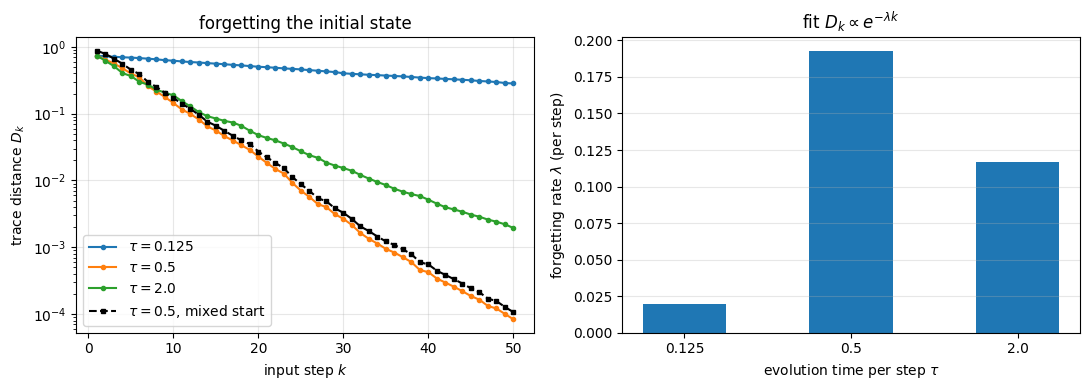

tau = 0.125:  D_1 = 0.7373, D_10 = 6.212e-01, D_50 = 2.831e-01, rate lambda = 0.020 per step  (memory time 1/lambda = 50.68 steps)
tau = 0.500:  D_1 = 0.7373, D_10 = 1.443e-01, D_50 = 8.352e-05, rate lambda = 0.192 per step  (memory time 1/lambda = 5.20 steps)
tau = 2.000:  D_1 = 0.7373, D_10 = 1.879e-01, D_50 = 1.945e-03, rate lambda = 0.117 per step  (memory time 1/lambda = 8.58 steps)
maximally mixed start, tau = 0.5: D_1 = 0.8750, D_50 = 1.067e-04

monotone decrease (no step increases D)? True


In [11]:
# ==============================================================================
# ECHO-STATE PROPERTY: two initial states, one input sequence, trace distance
# ==============================================================================
def make_echo_driver(L, R, tau, dt, order=2):
    """Drive TWO density tensors with the same input and record D_k = (1/2)||rho - rho'||_1."""
    n_sub = max(1, int(round(tau / dt)))

    def run(Js, hs, windows, rho_a, rho_b):
        gates = tebd_gates(hamiltonian_terms(Js, hs, L, R), tau / n_sub, order)

        def evolve(rho):
            return lax.scan(lambda r, _: (apply_gates_dm(r, gates), None), rho, None, length=n_sub)[0]

        def step(carry, u_window):
            ra, rb = carry
            ra = evolve(reset_and_encode_dm(ra, u_window, L))
            rb = evolve(reset_and_encode_dm(rb, u_window, L))
            return (ra, rb), trace_distance(dm_matrix(ra), dm_matrix(rb))

        return lax.scan(step, (rho_a, rho_b), windows)[1]

    return jax.jit(run)


u_echo = np.random.default_rng(3).uniform(0.0, 1.0, 50)
W_echo = input_windows(u_echo, L_IN)
rho_a0 = to_dm(zero_state(N_QUBITS))                                  # |0...0>
rho_b0 = to_dm(haar_state(jax.random.PRNGKey(11), N_QUBITS))          # a random pure state
rho_c0 = jnp.eye(2 ** N_QUBITS, dtype=CDTYPE).reshape((2,) * (2 * N_QUBITS)) / 2 ** N_QUBITS  # maximally mixed

taus_echo = (0.125, 0.5, 2.0)
D_curves = {}
for tau_e in taus_echo:
    drv_e = make_echo_driver(L_IN, N_RAILS, tau_e, DT)
    D_curves[tau_e] = np.asarray(drv_e(Js_demo, hs_demo, W_echo, rho_a0, rho_b0))
D_mixed = np.asarray(make_echo_driver(L_IN, N_RAILS, TAU, DT)(Js_demo, hs_demo, W_echo, rho_a0, rho_c0))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for tau_e in taus_echo:
    D = D_curves[tau_e]
    ax[0].semilogy(np.arange(1, len(D) + 1), np.maximum(D, 1e-17), "o-", ms=3,
                   label=rf"$\tau={tau_e}$")
ax[0].semilogy(np.arange(1, len(D_mixed) + 1), np.maximum(D_mixed, 1e-17), "s--", ms=3, color="k",
               label=rf"$\tau={TAU}$, mixed start")
ax[0].set_xlabel("input step $k$"); ax[0].set_ylabel(r"trace distance $D_k$")
ax[0].set_title("forgetting the initial state"); ax[0].legend(); ax[0].grid(alpha=0.3)

rates = {}
for tau_e in taus_echo:
    D = np.maximum(D_curves[tau_e], 1e-16)
    sel = (np.arange(len(D)) >= 2) & (D > 1e-12)
    rates[tau_e] = -np.polyfit(np.arange(len(D))[sel], np.log(D[sel]), 1)[0]
ax[1].bar([str(t) for t in taus_echo], [rates[t] for t in taus_echo], color="tab:blue", width=0.5)
ax[1].set_xlabel(r"evolution time per step $\tau$"); ax[1].set_ylabel(r"forgetting rate $\lambda$ (per step)")
ax[1].set_title(r"fit $D_k \propto e^{-\lambda k}$"); ax[1].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

for tau_e in taus_echo:
    D = D_curves[tau_e]
    print(f"tau = {tau_e:5.3f}:  D_1 = {D[0]:.4f}, D_10 = {D[9]:.3e}, D_50 = {D[-1]:.3e}, "
          f"rate lambda = {rates[tau_e]:.3f} per step  (memory time 1/lambda = {1/rates[tau_e]:.2f} steps)")
print(f"maximally mixed start, tau = {TAU}: D_1 = {D_mixed[0]:.4f}, D_50 = {D_mixed[-1]:.3e}")
print(f"\nmonotone decrease (no step increases D)? "
      f"{all(bool(np.all(np.diff(D_curves[t]) <= 1e-12)) for t in taus_echo)}")

Every curve decays to zero, and no step ever increases $D_k$: a trace-preserving positive map cannot increase the trace
distance, and the erasure of the input rail makes the decrease strict. Three features of the measurement:

* **The first step is the same for all three $\tau$**: $D_1=0.737$ everywhere. The unitary part leaves the trace distance
  invariant, so the only thing that acts on $D$ in one step is the erasure — and the erasure does not know $\tau$.
* **The rate is not monotonic in $\tau$.** The fitted $\lambda$ is $0.020$ at $\tau=0.125$, $0.192$ at $\tau=0.5$ and
  $0.117$ at $\tau=2$. Slow evolution barely moves the memory-rail information into the input qubit, so little of it is
  erased and the machine remembers its initial state for tens of steps; but a *longer* evolution is not monotonically
  better at destroying it, because what matters is how much of the initial-state information happens to sit on qubit $0$
  at the moment of the erasure, and that quantity oscillates with $\tau$.
* Starting from the maximally mixed state instead of a random pure state changes nothing qualitative ($D_1=0.875$ because
  the two states are more distinguishable to begin with, $D_{50}\approx10^{-4}$).

This is the *first* half of the trade-off of Section 2.3: slow forgetting means long memory. The second half — that a
reservoir which forgets too slowly has not mixed the input into its features either — is what the memory capacity of the
next section measures.

## 6. Memory capacity

We now drive the reservoir with an i.i.d. sequence $u_k\sim\mathcal{U}[0,1]$, the situation in which Jaeger's bound
$\mathrm{MC}\le p$ holds, and measure $C(\tau)$ of Eq. (5) for $\tau=1,\dots,20$ with the protocol of Section 2.5: washout,
contiguous train/validation/test blocks, $\alpha$ chosen on the validation block, $C(\tau)$ evaluated on the test block.
Every number is a median over `N_RES` random reservoirs, with the full spread shown as a band.

In [12]:
# ==============================================================================
# EXPERIMENT: memory capacity C(tau) = r^2 for the delay task, on the TEST block
# ==============================================================================
TAUS_MC = np.arange(1, 21)


def memory_capacity(F, u, taus=TAUS_MC, washout=WASHOUT):
    """C(tau) for every delay; features at step k, target u_{k-tau}.  Returns an array of r^2."""
    caps = []
    for tau in taus:
        _, r2, _, _, _ = evaluate(F[tau:], u[:len(u) - tau], washout=washout)
        caps.append(r2)
    return np.array(caps)


def drive_ensemble(L, R, tau, dt, u, V=1, n_res=N_RES, seed=SEED_RES, W=W_DIS, jump=None, gamma=0.0):
    """Drive `n_res` independent random reservoirs with the same input (vmap over disorder)."""
    keys = jax.random.split(jax.random.PRNGKey(seed), n_res)
    Js_b, hs_b = jax.vmap(lambda k: reservoir_params(k, L, R, W=W))(keys)
    drv = make_dm_driver(L, R, tau, dt, V=V, jump=jump, gamma=gamma)
    vdrv = jax.jit(jax.vmap(drv, in_axes=(0, 0, None, None)))
    rho0 = to_dm(zero_state(L * R))
    t0 = time.time()
    _, F = vdrv(Js_b, hs_b, input_windows(u, L), rho0)
    F = np.asarray(jax.block_until_ready(F))
    return F, time.time() - t0


rng_u = np.random.default_rng(2)
u_iid = rng_u.uniform(0.0, 1.0, T_LEN)                 # the i.i.d. drive used in Sections 6, 7, 9, 10

F_iid, t_drive = drive_ensemble(L_IN, N_RAILS, TAU, DT, u_iid)
print(f"{N_RES} reservoirs x {T_LEN} steps x {F_iid.shape[2]} features in {t_drive:.1f} s "
      f"({1e3*t_drive/(N_RES*T_LEN):.2f} ms per reservoir and step)")
caps_all = np.array([memory_capacity(F_iid[i], u_iid) for i in range(N_RES)])
MC_all = caps_all.sum(axis=1)

# Does the Trotter step matter for the SCORE (not for the state)?  Re-drive with dt/4.
F_fine, _ = drive_ensemble(L_IN, N_RAILS, TAU, DT / 4, u_iid)
MC_fine = np.array([memory_capacity(F_fine[i], u_iid).sum() for i in range(N_RES)])
print(f"Trotter check: MC with dt = {DT} : {np.array2string(MC_all, precision=3)}")
print(f"               MC with dt = {DT/4}: {np.array2string(MC_fine, precision=3)}")
print(f"               largest change {np.abs(MC_all - MC_fine).max():.4f}, "
      f"reservoir-to-reservoir spread {MC_all.max() - MC_all.min():.4f}\n")

print(f"median MC = {np.median(MC_all):.3f},  number of features p = {F_iid.shape[2]}  ->  Jaeger bound MC <= p")

# how many of the p features are linearly independent?
Xs = (F_iid[0][WASHOUT:] - F_iid[0][WASHOUT:].mean(0)) / np.maximum(F_iid[0][WASHOUT:].std(0), 1e-12)
sv = np.linalg.svd(Xs, compute_uv=False)
eff_rank = float(np.sum(sv) ** 2 / np.sum(sv ** 2))
print(f"singular values of the standardised feature matrix (reservoir 0): "
      f"{np.array2string(sv[:6]/sv[0], precision=3)} ... {sv[-1]/sv[0]:.2e}")
print(f"participation-ratio effective rank = {eff_rank:.2f} of {F_iid.shape[2]} columns")

6 reservoirs x 1200 steps x 21 features in 2.5 s (0.35 ms per reservoir and step)


Trotter check: MC with dt = 0.125 : [3.436 3.559 2.94  3.707 4.282 3.973]
               MC with dt = 0.03125: [3.435 3.677 2.907 3.71  4.259 3.94 ]
               largest change 0.1179, reservoir-to-reservoir spread 1.3425

median MC = 3.633,  number of features p = 21  ->  Jaeger bound MC <= p
singular values of the standardised feature matrix (reservoir 0): [1.    0.849 0.763 0.738 0.598 0.558] ... 6.76e-02
participation-ratio effective rank = 14.50 of 21 columns


tau sweep: 5 ensembles driven in 14.4 s


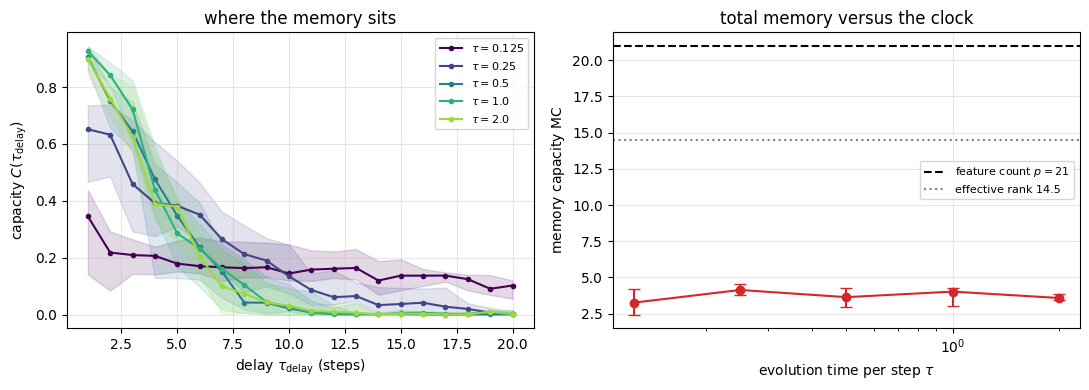

 tau      MC (median)   [min, max] over reservoirs   C(1)    C(5)
 0.125       3.257      [2.423, 4.188]        0.346   0.180
 0.250       4.129      [3.789, 4.513]        0.652   0.383
 0.500       3.633      [2.940, 4.282]        0.905   0.348
 1.000       4.017      [3.019, 4.270]        0.928   0.286
 2.000       3.576      [3.457, 3.840]        0.899   0.380


In [13]:
# ==============================================================================
# EXPERIMENT: C(tau) profile, and MC against the evolution time tau
# ==============================================================================
TAU_SWEEP = (0.125, 0.25, 0.5, 1.0, 2.0)
caps_by_tau, t_total = {}, 0.0
for tau_s in TAU_SWEEP:
    F_s, dt_s = drive_ensemble(L_IN, N_RAILS, tau_s, DT, u_iid)
    caps_by_tau[tau_s] = np.array([memory_capacity(F_s[i], u_iid) for i in range(N_RES)])
    t_total += dt_s
print(f"tau sweep: {len(TAU_SWEEP)} ensembles driven in {t_total:.1f} s")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
colors = plt.cm.viridis(np.linspace(0, 0.85, len(TAU_SWEEP)))
for c, tau_s in zip(colors, TAU_SWEEP):
    C = caps_by_tau[tau_s]
    ax[0].plot(TAUS_MC, np.median(C, axis=0), "o-", ms=3, color=c, label=rf"$\tau={tau_s}$")
    ax[0].fill_between(TAUS_MC, C.min(axis=0), C.max(axis=0), color=c, alpha=0.15)
ax[0].set_xlabel(r"delay $\tau_{\rm delay}$ (steps)"); ax[0].set_ylabel(r"capacity $C(\tau_{\rm delay})$")
ax[0].set_title("where the memory sits"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

mc_med = [np.median(caps_by_tau[t].sum(axis=1)) for t in TAU_SWEEP]
mc_lo = [caps_by_tau[t].sum(axis=1).min() for t in TAU_SWEEP]
mc_hi = [caps_by_tau[t].sum(axis=1).max() for t in TAU_SWEEP]
ax[1].errorbar(TAU_SWEEP, mc_med, yerr=[np.array(mc_med) - mc_lo, np.array(mc_hi) - np.array(mc_med)],
               fmt="o-", capsize=4, color="tab:red")
ax[1].axhline(F_iid.shape[2], ls="--", color="k", label=rf"feature count $p={F_iid.shape[2]}$")
ax[1].axhline(eff_rank, ls=":", color="gray", label=f"effective rank {eff_rank:.1f}")
ax[1].set_xscale("log"); ax[1].set_xlabel(r"evolution time per step $\tau$")
ax[1].set_ylabel(r"memory capacity $\mathrm{MC}$")
ax[1].set_title("total memory versus the clock"); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(" tau      MC (median)   [min, max] over reservoirs   C(1)    C(5)")
for tau_s in TAU_SWEEP:
    C = caps_by_tau[tau_s]
    m = C.sum(axis=1)
    print(f"{tau_s:6.3f}    {np.median(m):8.3f}      [{m.min():.3f}, {m.max():.3f}]        "
          f"{np.median(C[:, 0]):.3f}   {np.median(C[:, 4]):.3f}")

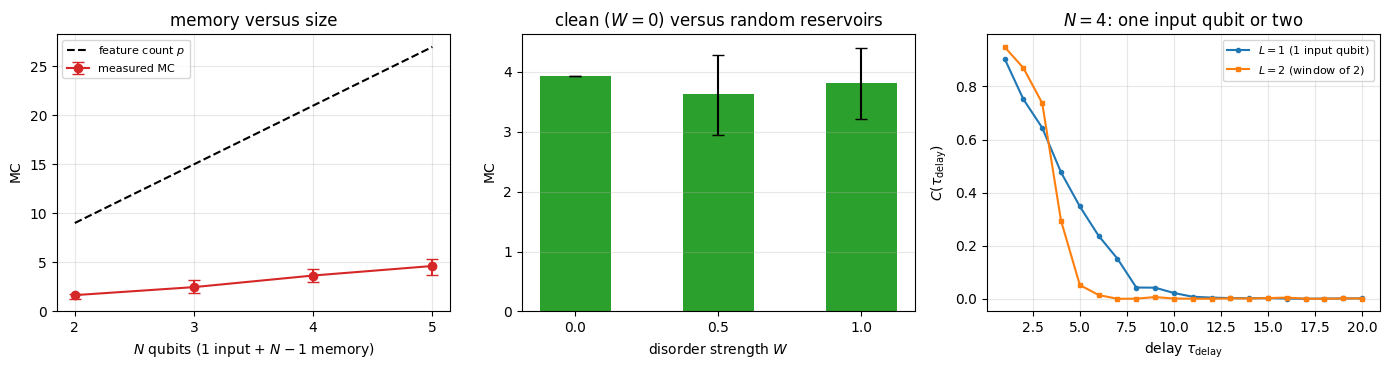

N   p    MC median   [min, max]
2    9     1.628    [1.251, 1.728]
3   15     2.448    [1.869, 3.147]
4   21     3.633    [2.940, 4.282]
5   27     4.606    [3.678, 5.347]

W      MC median
 0.0     3.939    [3.939, 3.939]
 0.5     3.633    [2.940, 4.282]
 1.0     3.823    [3.212, 4.408]

L=1, N=4: MC = 3.633, C(1) = 0.905, C(2) = 0.752, p = 21
L=2, N=4: MC = 2.999, C(1) = 0.949, C(2) = 0.870, p = 24


In [14]:
# ==============================================================================
# EXPERIMENT: MC against the number of qubits, the disorder, the input-rail length
# ==============================================================================
N_SWEEP = (2, 3, 4, 5)
mc_vs_N, p_vs_N = {}, {}
for R_s in N_SWEEP:
    F_s, _ = drive_ensemble(1, R_s, TAU, DT, u_iid)
    mc_vs_N[R_s] = np.array([memory_capacity(F_s[i], u_iid).sum() for i in range(N_RES)])
    p_vs_N[R_s] = F_s.shape[2]

mc_vs_W = {}
for W_s in (0.0, 0.5, 1.0):
    F_s, _ = drive_ensemble(L_IN, N_RAILS, TAU, DT, u_iid, W=W_s)
    mc_vs_W[W_s] = np.array([memory_capacity(F_s[i], u_iid).sum() for i in range(N_RES)])

F_L2, _ = drive_ensemble(2, 2, TAU, DT, u_iid)          # the 2 x 2 plaquette: two input qubits
caps_L2 = np.array([memory_capacity(F_L2[i], u_iid) for i in range(N_RES)])

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
ax[0].errorbar(N_SWEEP, [np.median(mc_vs_N[n]) for n in N_SWEEP],
               yerr=[[np.median(mc_vs_N[n]) - mc_vs_N[n].min() for n in N_SWEEP],
                     [mc_vs_N[n].max() - np.median(mc_vs_N[n]) for n in N_SWEEP]],
               fmt="o-", capsize=4, color="tab:red", label="measured MC")
ax[0].plot(N_SWEEP, [p_vs_N[n] for n in N_SWEEP], "k--", label="feature count $p$")
ax[0].set_xlabel("$N$ qubits ($1$ input $+$ $N-1$ memory)"); ax[0].set_ylabel(r"$\mathrm{MC}$")
ax[0].set_xticks(N_SWEEP); ax[0].set_title("memory versus size"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].bar([f"{w}" for w in mc_vs_W], [np.median(v) for v in mc_vs_W.values()],
          yerr=[[np.median(v) - v.min() for v in mc_vs_W.values()],
                [v.max() - np.median(v) for v in mc_vs_W.values()]],
          capsize=4, color="tab:green", width=0.5)
ax[1].set_xlabel("disorder strength $W$"); ax[1].set_ylabel(r"$\mathrm{MC}$")
ax[1].set_title(r"clean ($W=0$) versus random reservoirs"); ax[1].grid(alpha=0.3, axis="y")

ax[2].plot(TAUS_MC, np.median(caps_all, axis=0), "o-", ms=3, label=r"$L=1$ (1 input qubit)")
ax[2].plot(TAUS_MC, np.median(caps_L2, axis=0), "s-", ms=3, label=r"$L=2$ (window of 2)")
ax[2].set_xlabel(r"delay $\tau_{\rm delay}$"); ax[2].set_ylabel(r"$C(\tau_{\rm delay})$")
ax[2].set_title(r"$N=4$: one input qubit or two"); ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("N   p    MC median   [min, max]")
for n in N_SWEEP:
    print(f"{n}  {p_vs_N[n]:3d}   {np.median(mc_vs_N[n]):7.3f}    [{mc_vs_N[n].min():.3f}, {mc_vs_N[n].max():.3f}]")
print("\nW      MC median")
for w, v in mc_vs_W.items():
    print(f"{w:4.1f}   {np.median(v):7.3f}    [{v.min():.3f}, {v.max():.3f}]")
print(f"\nL=1, N=4: MC = {np.median(caps_all.sum(1)):.3f}, C(1) = {np.median(caps_all[:,0]):.3f}, "
      f"C(2) = {np.median(caps_all[:,1]):.3f}, p = {F_iid.shape[2]}")
print(f"L=2, N=4: MC = {np.median(caps_L2.sum(1)):.3f}, C(1) = {np.median(caps_L2[:,0]):.3f}, "
      f"C(2) = {np.median(caps_L2[:,1]):.3f}, p = {F_L2.shape[2]}")

In [15]:
# ==============================================================================
# EXPERIMENT: temporal multiplexing -- V readouts inside one interval tau
# ==============================================================================
V_SWEEP = (1, 2, 4)
F_by_V, caps_by_V = {}, {}
for V_s in V_SWEEP:
    F_by_V[V_s], dt_s = drive_ensemble(L_IN, N_RAILS, TAU, DT, u_iid, V=V_s)
    caps_by_V[V_s] = np.array([memory_capacity(F_by_V[V_s][i], u_iid) for i in range(N_RES)])
    print(f"V = {V_s}: p = {F_by_V[V_s].shape[2]:3d} features, "
          f"MC = {np.median(caps_by_V[V_s].sum(1)):.3f} "
          f"[{caps_by_V[V_s].sum(1).min():.3f}, {caps_by_V[V_s].sum(1).max():.3f}]  ({dt_s:.1f} s)")

V = 1: p =  21 features, MC = 3.633 [2.940, 4.282]  (2.6 s)


V = 2: p =  42 features, MC = 4.083 [3.260, 4.623]  (3.5 s)


V = 4: p =  84 features, MC = 4.405 [3.696, 5.110]  (3.9 s)


### 6.1 What the memory measurements say

* **The capacity profile moves, the total does not.** $C(\tau_{\rm delay})$ starts near $1$ and decays over a few steps.
  At $\tau=0.125$ the first delay is poorly resolved ($C(1)=0.35$) but a weak tail survives to $\tau_{\rm delay}=20$; at
  $\tau\ge0.5$ the first two delays are almost perfect ($C(1)\approx0.9$) and nothing is left after ten steps. The *total*
  is $3.3$–$4.1$ across a sixteenfold range of $\tau$, with a reservoir-to-reservoir spread of about $\pm0.7$ that is
  larger than the trend. A conserved total with a redistributable profile is exactly the behaviour of the capacity sum
  rule of Dambre *et al.*
* **The bound is satisfied with room to spare**: $\mathrm{MC}=3.63$ against $p=21$ features. Part of the gap is
  redundancy — the singular values of the standardised feature matrix span a factor of $15$ and the
  participation-ratio effective rank is $14.5$, not $21$ — but even against $14.5$ the measured capacity is small. The
  rest of the gap is that the bound is saturated only by a *complete* set of target functionals; the delay task probes
  the linear ones only, and the remaining capacity sits in the nonlinear functionals that Sections 7 and 8 exploit.
* **Size helps, roughly linearly**: $1.63,\,2.45,\,3.63,\,4.61$ for $N=2,3,4,5$, i.e. about one extra delay remembered
  per added memory qubit, while the feature count grows by six per qubit. The $4^N$-dimensional state space is
  emphatically *not* converted into $4^N$ usable memory slots by a readout of one- and two-body observables.
* **Disorder is not the point.** The clean lattice ($W=0$) reaches $\mathrm{MC}=3.94$ — above the median of the
  disordered ensembles ($3.63$ at $W=0.5$, $3.82$ at $W=1$) and inside their spread. (All six $W=0$ "draws" are the same
  Hamiltonian, which is why that bar has no error bar at all: a useful check that the spread really comes from the
  disorder.) What disorder buys is not performance but the possibility of *statistics*: a family of machines rather than
  one.
* **Where to put the input.** With $L=2$ the two most recent inputs are written into the register at every step, so
  $C(1)=0.95$ and $C(2)=0.87$ are high for a trivial reason — they are read off the input rail, not recalled. But only
  two qubits are left to remember anything, the profile collapses after $\tau_{\rm delay}=4$, and the total
  ($\mathrm{MC}=3.00$ with $p=24$) is *below* the single-input-qubit machine ($3.63$ with $p=21$).
* **Multiplexing** raises the capacity at fixed hardware — $3.63\to4.08\to4.41$ for $V=1,2,4$ — and by far less than the
  factor $V$ by which the feature count grows. The $V$ snapshots inside one interval are strongly correlated with each
  other, which is the same redundancy that the effective rank already exposed.

## 7. NARMA: memory *and* nonlinearity

The delay task is linear in the input, so a reservoir could score well on it with no nonlinearity at all. NARMA is the
standard cure: Eqs. (6) and (7) define a target that depends on products of past inputs and on its own past. We drive with
the same i.i.d. sequence as in Section 6, rescaled to the interval $[0,0.5]$ that the NARMA literature uses, and train the
same ridge readout. The baselines are trained on exactly the same blocks with exactly the same $\alpha$ grid: a linear
autoregression on the last $p$ inputs, and a classical echo-state network with $p$ units.

In [16]:
# ==============================================================================
# EXPERIMENT: NARMA-2, NARMA-5, NARMA-10 -- quantum reservoir versus baselines
# ==============================================================================
u_narma = 0.5 * u_iid                       # the drive encoded in the qubit is u_iid; NARMA sees u_iid/2
targets = {"NARMA-2": narma2(u_narma), "NARMA-5": narma_n(u_narma, 5), "NARMA-10": narma_n(u_narma, 10)}
p_feat = F_iid.shape[2]

rows = []
for name, y in targets.items():
    q = np.array([evaluate(F_iid[i], y)[0] for i in range(N_RES)])
    q4 = np.array([evaluate(F_by_V[4][i], y)[0] for i in range(N_RES)])
    ar = evaluate(ar_features(u_iid, p_feat), y)[0]
    esn = np.array([evaluate(esn_features(u_iid, p_feat, seed=s), y)[0] for s in range(N_RES)])
    esn_big = np.array([evaluate(esn_features(u_iid, 200, seed=s), y)[0] for s in range(N_RES)])
    rows.append((name, np.median(q), q.min(), q.max(), np.median(q4), ar, np.median(esn), np.median(esn_big)))

# how linear are the two nonlinearities involved?
print(f"correlation of the NARMA input nonlinearity with the input itself: "
      f"corr(u, u^3) = {np.corrcoef(u_narma, u_narma**3)[0, 1]:.4f} on [0, 0.5]")
print(f"correlation of the encoding with the input: corr(u, cos(pi u)) = "
      f"{np.corrcoef(u_iid, np.cos(np.pi*u_iid))[0, 1]:+.4f}, corr(u, sin(pi u)) = "
      f"{np.corrcoef(u_iid, np.sin(np.pi*u_iid))[0, 1]:+.4f}\n")
print(f"test NMSE (median over {N_RES} reservoirs / seeds); p = {p_feat} features for QRC, AR and the small ESN")
print(f"{'task':10s} {'QRC V=1':>18s} {'QRC V=4':>9s} {'AR(p)':>9s} {'ESN(p)':>9s} {'ESN(200)':>10s}")
for name, med, lo, hi, med4, ar, esn, esn_big in rows:
    print(f"{name:10s} {med:8.4f} [{lo:.3f},{hi:.3f}] {med4:9.4f} {ar:9.4f} {esn:9.4f} {esn_big:10.4f}")

correlation of the NARMA input nonlinearity with the input itself: corr(u, u^3) = 0.9206 on [0, 0.5]
correlation of the encoding with the input: corr(u, cos(pi u)) = -0.9930, corr(u, sin(pi u)) = -0.0576

test NMSE (median over 6 reservoirs / seeds); p = 21 features for QRC, AR and the small ESN
task                  QRC V=1   QRC V=4     AR(p)    ESN(p)   ESN(200)
NARMA-2      0.3198 [0.282,0.468]    0.2226    0.1524    0.1474     0.0186
NARMA-5      0.6176 [0.572,0.708]    0.4838    0.1324    0.2740     0.0301
NARMA-10     0.7842 [0.666,0.844]    0.7494    0.1872    0.6896     0.2532


**The quantum reservoir loses this one, and the reason is instructive.** With $p=21$ features it reaches a test NMSE of
$0.32$ on NARMA-2, $0.62$ on NARMA-5 and $0.78$ on NARMA-10; the linear autoregression on the last $21$ inputs reaches
$0.15$, $0.13$ and $0.19$, and the classical echo-state network with $21$ units $0.15$, $0.27$ and $0.69$. Multiplexing to
$84$ features helps ($0.22$, $0.48$, $0.75$) but does not change the ordering.

Two measured facts explain it.

1. **NARMA is mostly a memory task, and memory is what our machine is short of.** The target of Eq. (7) depends on the
   last $n$ inputs and, through its own past, on a long exponential tail of earlier ones. The autoregressive baseline is
   *given* the last $21$ inputs exactly — a memory capacity of $21$ by construction — while the reservoir has
   $\mathrm{MC}=3.6$. For NARMA-5 and NARMA-10 that is simply not enough, and no amount of nonlinearity repairs it.
2. **The nonlinearity NARMA asks for is weak.** The only explicitly nonlinear input term in Eq. (6) is $u^3$, and on
   $[0,0.5]$ the correlation between $u$ and $u^3$ is $0.921$: some $85\,\%$ of the variance of $u_k^3$ is already
   contained in $u_k$ itself. A linear filter of the past inputs therefore captures most of the target, which is why
   $\mathrm{AR}(21)$ — a model with no nonlinearity whatsoever — is hard to beat here.

The same table also shows the honest cost of the "equal number of features" convention: $21$ exact input lags are $21$
linearly independent numbers, while $21$ quantum expectation values have an effective rank of $14.5$ and encode a memory
of less than four steps. Section 10 returns to NARMA-2 with a dissipative reservoir, where the picture changes.

## 8. The Santa Fe laser series

Data set A of the Santa Fe time-series competition is a univariate record of the intensity of an
$81.5\,\mu\mathrm{m}$ $^{14}$NH$_3$ far-infrared laser in a chaotic regime — the experiment of U. Hübner with
N. B. Abraham and C. O. Weiss, contributed to the competition whose proceedings Weigend and Gershenfeld edited. The
intensity was digitised to $8$ bits, and the series alternates between stretches of growing oscillations and abrupt
collapses. The competition data set is $1000$ points long with a continuation of about $10^4$ further points; the file
`../data/santafe.txt` holds $4000$ samples of the series, standardised to zero mean and unit variance. The quantisation
is still visible: the distinct values lie on a uniform lattice, which the cell below verifies.

4000 samples, mean +4.439e-07, std 0.999875, min -1.1859, max 4.0036
229 distinct values; smallest gap 0.02050; the values fit the lattice min + n*gap with n = 0..253 to within 3.0e-03 (the file stores 5 digits) -- an 8-bit digitisation
working series: 1200 points -> washout 100, train 660, validation 220, test 220
autocorrelation of the series at lag 1: 0.5315 (the i.i.d. drive of Section 6: -0.0105)


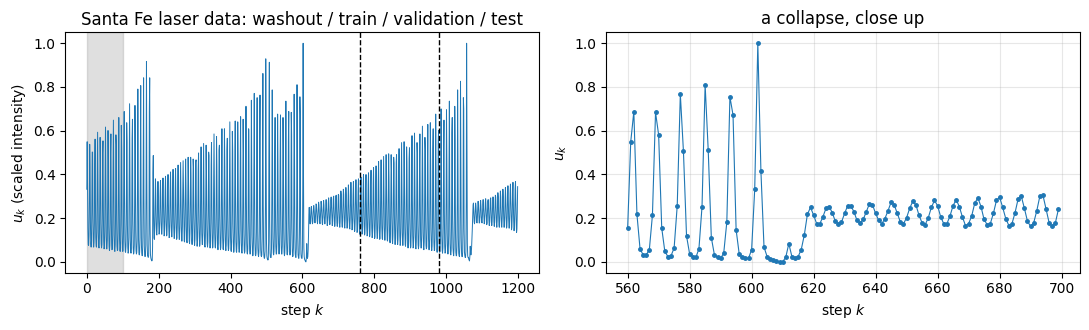

In [17]:
# ==============================================================================
# DATA: the Santa Fe laser series
# ==============================================================================
santafe_raw = np.loadtxt("../data/santafe.txt")
print(f"{len(santafe_raw)} samples, mean {santafe_raw.mean():+.3e}, std {santafe_raw.std():.6f}, "
      f"min {santafe_raw.min():.4f}, max {santafe_raw.max():.4f}")

uniq = np.unique(santafe_raw)
step = np.diff(uniq).min()
levels = np.round((santafe_raw - santafe_raw.min()) / step)
resid = np.abs(santafe_raw - (levels * step + santafe_raw.min())).max()
print(f"{len(uniq)} distinct values; smallest gap {step:.5f}; the values fit the lattice "
      f"min + n*gap with n = 0..{int(levels.max())} to within {resid:.1e} (the file stores 5 digits) "
      f"-- an 8-bit digitisation")

s_sf = santafe_raw[:T_LEN]
u_sf = (s_sf - s_sf.min()) / (s_sf.max() - s_sf.min())          # min-max to [0,1] for the encoding
tr_sf, va_sf, te_sf = split_indices(T_LEN, WASHOUT)
print(f"working series: {T_LEN} points -> washout {WASHOUT}, train {tr_sf.stop-tr_sf.start}, "
      f"validation {va_sf.stop-va_sf.start}, test {te_sf.stop-te_sf.start}")
print(f"autocorrelation of the series at lag 1: {np.corrcoef(u_sf[1:], u_sf[:-1])[0,1]:.4f} "
      f"(the i.i.d. drive of Section 6: {np.corrcoef(u_iid[1:], u_iid[:-1])[0,1]:+.4f})")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(np.arange(T_LEN), u_sf, lw=0.7, color="tab:blue")
for x, c in ((tr_sf.stop, "k"), (va_sf.stop, "k")):
    ax[0].axvline(x, color=c, ls="--", lw=1)
ax[0].axvspan(0, WASHOUT, color="gray", alpha=0.25)
ax[0].set_xlabel("step $k$"); ax[0].set_ylabel(r"$u_k$ (scaled intensity)")
ax[0].set_title("Santa Fe laser data: washout / train / validation / test")
ax[1].plot(np.arange(560, 700), u_sf[560:700], "o-", ms=2.5, lw=0.8, color="tab:blue")
ax[1].set_xlabel("step $k$"); ax[1].set_ylabel(r"$u_k$"); ax[1].set_title("a collapse, close up")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

two ensembles driven with the laser series in 6.3 s



test NMSE of predicting u(k+h) -- median over 6 reservoirs / seeds
model                h=1       h=2       h=4       h=8
QRC $V=1$         0.0931    0.2680    0.2907    0.2543
QRC $V=4$         0.0244    0.1684    0.1773    0.1450
AR(21)            0.2602    0.3865    0.3480    0.3582
ESN(21)           0.0971    0.2952    0.3010    0.2542
ESN(200)          0.0124    0.1270    0.1409    0.1274


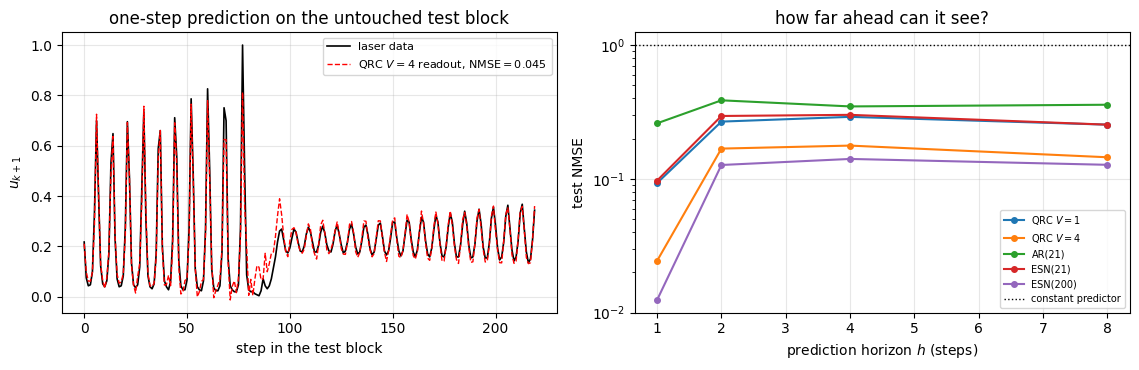


single configuration shown in the left panel: reservoir 0, V=4, h=1: NMSE 0.0453, r^2 0.9572, alpha chosen on the validation block = 0.1


In [18]:
# ==============================================================================
# EXPERIMENT: one-step and multi-step prediction of the laser series
# ==============================================================================
HORIZONS = (1, 2, 4, 8)
F_sf1, t_sf1 = drive_ensemble(L_IN, N_RAILS, TAU, DT, u_sf, V=1)
F_sf4, t_sf4 = drive_ensemble(L_IN, N_RAILS, TAU, DT, u_sf, V=4)
print(f"two ensembles driven with the laser series in {t_sf1 + t_sf4:.1f} s")


def horizon_scores(F, u, h):
    """NMSE of predicting u_{k+h} from the features at step k."""
    return evaluate(F[:len(u) - h], u[h:])


res_sf = {"QRC $V=1$": np.array([[horizon_scores(F_sf1[i], u_sf, h)[0] for h in HORIZONS] for i in range(N_RES)]),
          "QRC $V=4$": np.array([[horizon_scores(F_sf4[i], u_sf, h)[0] for h in HORIZONS] for i in range(N_RES)]),
          f"AR({p_feat})": np.array([[horizon_scores(ar_features(u_sf, p_feat), u_sf, h)[0] for h in HORIZONS]]),
          f"ESN({p_feat})": np.array([[horizon_scores(esn_features(u_sf, p_feat, seed=s), u_sf, h)[0]
                                       for h in HORIZONS] for s in range(N_RES)]),
          "ESN(200)": np.array([[horizon_scores(esn_features(u_sf, 200, seed=s), u_sf, h)[0]
                                 for h in HORIZONS] for s in range(N_RES)])}

print(f"\ntest NMSE of predicting u(k+h) -- median over {N_RES} reservoirs / seeds")
print(f"{'model':14s}" + "".join(f"{'h='+str(h):>10s}" for h in HORIZONS))
for name, arr in res_sf.items():
    print(f"{name:14s}" + "".join(f"{np.median(arr[:, j]):10.4f}" for j in range(len(HORIZONS))))

nmse_best, r2_best, alpha_best, yp_best, yt_best = horizon_scores(F_sf4[0], u_sf, 1)   # one reservoir, not the best
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8))
ax[0].plot(yt_best, "k-", lw=1.2, label="laser data")
ax[0].plot(yp_best, "r--", lw=1.0, label=rf"QRC $V=4$ readout, NMSE$={nmse_best:.3f}$")
ax[0].set_xlabel("step in the test block"); ax[0].set_ylabel(r"$u_{k+1}$")
ax[0].set_title("one-step prediction on the untouched test block"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
for name, arr in res_sf.items():
    ax[1].plot(HORIZONS, np.median(arr, axis=0), "o-", ms=4, label=name)
ax[1].axhline(1.0, color="k", ls=":", lw=1, label=r"constant predictor")
ax[1].set_xlabel("prediction horizon $h$ (steps)"); ax[1].set_ylabel("test NMSE")
ax[1].set_yscale("log"); ax[1].set_title("how far ahead can it see?"); ax[1].legend(fontsize=7); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"\nsingle configuration shown in the left panel: reservoir 0, V=4, h=1: NMSE {nmse_best:.4f}, r^2 {r2_best:.4f}, "
      f"alpha chosen on the validation block = {alpha_best:g}")

On real data the ordering reverses. For one-step prediction the quantum reservoir reaches a test NMSE of $0.093$ with
$21$ features and $0.024$ with $84$; the linear autoregression on $21$ lags reaches only $0.26$, and the classical
echo-state network with the same $21$ units $0.097$. Two conclusions, both visible in the right-hand panel:

* **Against the linear model the quantum reservoir wins by a factor of three**, and that gap is exactly the nonlinearity
  of Eq. (14) at work. The laser series is strongly autocorrelated (lag-1 correlation $0.53$) and its collapses are
  intrinsically nonlinear events; a linear filter of the past interpolates the oscillation but cannot anticipate a
  collapse. The left-hand panel shows the reservoir tracking the amplitude growth and the collapse near step $80$ of the
  test block, with a visible but bounded error right at the discontinuity.
* **Against the classical reservoir with the same number of readout features it is a draw** ($0.093$ against $0.097$ at
  $V=1$), and a classical network with $200$ units — which costs microseconds to simulate — is better than both
  ($0.012$). At $N=4$ qubits there is no computational advantage here, and claiming one would require counting resources
  very carefully in the other direction.

Beyond one step the task becomes much harder for everybody: the NMSE at $h=2$ is three to seven times the $h=1$ value for
every model. The oscillation period of the series is about seven samples, so a two-step horizon already requires
extrapolating the *phase* of the pulsation, not only its envelope. The curves then flatten, because at $h=4$ and $h=8$ all
models have fallen back on predicting the slowly varying envelope.

## 9. What a readout costs: finite measurement statistics

Every feature used so far is an exact expectation value $\mathrm{Tr}(\rho_k O)$ — a number that no experiment ever
measures. A real device prepares the state, measures, and gets one $\pm1$ outcome per observable. The estimator from $M$
repetitions of a Pauli observable with true value $f=\langle O\rangle$ is

$$ \hat f=\frac1M\sum_{s=1}^{M}o_s,\qquad o_s=\pm1,\qquad p(\pm1)=\frac{1\pm f}{2},
   \qquad \operatorname{Var}(\hat f)=\frac{1-f^2}{M} . \tag{15}$$

Three facts turn this into a real cost:

1. **Incompatible settings.** $X$, $Y$ and $Z$ on the same qubit cannot be measured in the same run. The feature set of
   Eq. (13) needs three settings, so $M$ repetitions per feature means $3M$ runs.
2. **The measurement destroys the state.** To read the reservoir at step $k$ and then continue to step $k+1$ with the
   *same* state is not possible. In the restarting protocol the whole input sequence up to step $k$ must be replayed for
   every readout time, which makes the experimental time grow quadratically with the length of the series. Mujal,
   Martínez-Peña, Giorgi, Soriano and Zambrini analysed exactly this and proposed two ways out: a *rewinding* protocol that
   replays only the washout window, using the fading memory established in Section 5, and an *online* protocol with weak
   (continuous) measurements that never repeats the dynamics but pays with measurement back-action.
3. **The noise enters the regression.** Noisy features make $X^{\rm T}X$ worse conditioned; the ridge parameter chosen on
   the validation block is what keeps the readout from amplifying the noise, and it grows as $M$ falls.

First a check that Eq. (15) really describes what our simulator would produce. We take the $M$ *trajectories* of Section
4.5 — each one an independent experimental run, including the randomness of the reset — measure every qubit once in the
$Z$ basis of the final state, average, and compare the spread over repetitions with $\sqrt{(1-f^2)/M}$.

In [19]:
# ==============================================================================
# CHECKPOINT: the shot model (15) against a full simulation of the measurement
# ==============================================================================
M_SHOT, R_REP, K_STEPS = 100, 20, 40
u_shot = np.random.default_rng(7).uniform(0.0, 1.0, K_STEPS)
W_shot = input_windows(u_shot, L_IN)
keys_shot = jax.random.split(jax.random.PRNGKey(21), M_SHOT * R_REP)
psi_end, _ = jax.jit(jax.vmap(mcwf, in_axes=(None, None, None, None, 0)))(
    Js_demo, hs_demo, W_shot, zero_state(N_QUBITS), keys_shot)
bits = jax.vmap(lambda k, p: sample_bitstrings(k, p, 1)[0])(
    jax.random.split(jax.random.PRNGKey(22), M_SHOT * R_REP), psi_end)
z_vals = np.asarray(1 - 2 * bits, dtype=float).reshape(R_REP, M_SHOT, N_QUBITS)   # +-1 outcomes
est = z_vals.mean(axis=1)                                                          # (R_REP, N) estimates of <Z_q>
f_exact = np.asarray(driver_ml(Js_demo, hs_demo, W_shot, to_dm(zero_state(N_QUBITS)))[1])[-1, 2:3 * N_QUBITS:3]
print("qubit   exact <Z>    mean of estimates    spread over repetitions    sqrt((1-f^2)/M)")
for q in range(N_QUBITS):
    print(f"  {q}     {f_exact[q]:+.4f}      {est[:, q].mean():+.4f}              {est[:, q].std(ddof=1):.4f}"
          f"                 {np.sqrt((1 - f_exact[q]**2)/M_SHOT):.4f}")

qubit   exact <Z>    mean of estimates    spread over repetitions    sqrt((1-f^2)/M)
  0     +0.0283      +0.0500              0.1049                 0.1000
  1     +0.1736      +0.1840              0.1167                 0.0985
  2     -0.0828      -0.1200              0.0934                 0.0997
  3     +0.0507      +0.0620              0.0986                 0.0999


The simulated experiment — $20$ independent repetitions of "drive $100$ trajectories, measure each once" — reproduces
Eq. (15): the mean of the estimates agrees with the exact expectation value within its own standard error, and the spread
over repetitions matches $\sqrt{(1-f^2)/M}$ within the $16\,\%$ uncertainty that an rms from $20$ samples carries. Two
sources of randomness are folded into that one number — which reset outcomes the run happened to produce, and which
eigenvalue the final measurement returned — and together they give exactly the variance of the observable in the state
$\rho_k$, as they must.

That justifies the shortcut used below: instead of simulating $M$ trajectories for every point of a sweep, draw each
feature from the binomial distribution of Eq. (15) around its exact value. The model is validated, it is a thousand times
cheaper, and it makes the $M$ dependence exact rather than noisy.

> **Common pitfall.** `sample_bitstrings` builds a `(shots, 2^N)` array of log-probabilities, so `vmap`-ing it over
> thousands of repetitions is only safe because $N=4$ here. At $N=16$ the same line would try to allocate gigabytes; the
> cure is to loop over repetitions or to sample a sufficient statistic (see
> [notebook 08](../ch03_matrix_free_engine/08_measurements.ipynb)).

M =    30 (  90 runs of the sequence per readout time):  NARMA-2 NMSE 0.5350 (unregularised 0.5353), Santa Fe NMSE 0.5708


M =   100 ( 300 runs of the sequence per readout time):  NARMA-2 NMSE 0.3985 (unregularised 0.3985), Santa Fe NMSE 0.4235
M =   300 ( 900 runs of the sequence per readout time):  NARMA-2 NMSE 0.3515 (unregularised 0.3513), Santa Fe NMSE 0.2901


M =  1000 (3000 runs of the sequence per readout time):  NARMA-2 NMSE 0.3305 (unregularised 0.3299), Santa Fe NMSE 0.2054
M =  3000 (9000 runs of the sequence per readout time):  NARMA-2 NMSE 0.3198 (unregularised 0.3199), Santa Fe NMSE 0.1499


M = 10000 (30000 runs of the sequence per readout time):  NARMA-2 NMSE 0.3207 (unregularised 0.3206), Santa Fe NMSE 0.1321
M =  None (                  exact expectation values):  NARMA-2 NMSE 0.3198 (unregularised 0.3198), Santa Fe NMSE 0.0931


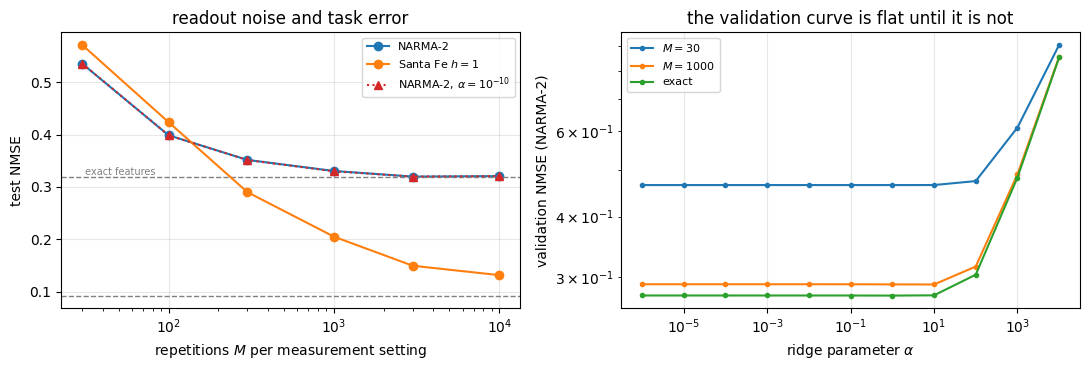

In [20]:
# ==============================================================================
# EXPERIMENT: task error versus the number of measurement repetitions
# ==============================================================================
M_SWEEP = (30, 100, 300, 1000, 3000, 10000)
rng_shot = np.random.default_rng(99)


def add_shot_noise(F, M, rng):
    """Replace each exact feature f by an estimate from M repetitions:  (2 Binomial(M,(1+f)/2) - M)/M."""
    p = np.clip(0.5 * (1.0 + F), 0.0, 1.0)
    return 2.0 * rng.binomial(M, p) / M - 1.0


shot_curves = {"NARMA-2": [], "Santa Fe $h=1$": []}
unreg_curve, val_curves = [], {}
for M in M_SWEEP + (None,):
    nn, sf, nn_raw = [], [], []
    for i in range(N_RES):
        F_n = F_iid[i] if M is None else add_shot_noise(F_iid[i], M, rng_shot)
        F_s = F_sf1[i] if M is None else add_shot_noise(F_sf1[i], M, rng_shot)
        e_nn, _, a, _, _, curve = evaluate(F_n, targets["NARMA-2"], return_curve=True)
        nn.append(e_nn)
        # the SAME fit with the regularisation switched off, to see what alpha is worth
        nn_raw.append(evaluate(F_n, targets["NARMA-2"], alphas=[1e-10])[0])
        sf.append(horizon_scores(F_s, u_sf, 1)[0])
        if i == 0 and M in (M_SWEEP[0], M_SWEEP[3], None):
            val_curves[M] = curve
    shot_curves["NARMA-2"].append(np.median(nn))
    shot_curves["Santa Fe $h=1$"].append(np.median(sf))
    unreg_curve.append(np.median(nn_raw))
    runs = "exact expectation values" if M is None else f"{3*M} runs of the sequence per readout time"
    print(f"M = {str(M):>5s} ({runs:>42s}):  NARMA-2 NMSE {np.median(nn):.4f} "
          f"(unregularised {np.median(nn_raw):.4f}), Santa Fe NMSE {np.median(sf):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for name, v in shot_curves.items():
    ax[0].semilogx(M_SWEEP, v[:-1], "o-", label=name)
    ax[0].axhline(v[-1], ls="--", lw=1, color="gray")
ax[0].semilogx(M_SWEEP, unreg_curve[:-1], "^:", color="tab:red", label=r"NARMA-2, $\alpha=10^{-10}$")
ax[0].set_xlabel("repetitions $M$ per measurement setting"); ax[0].set_ylabel("test NMSE")
ax[0].set_title("readout noise and task error"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
ax[0].text(M_SWEEP[0], shot_curves["NARMA-2"][-1], " exact features", fontsize=7, va="bottom", color="gray")
for M, curve in val_curves.items():
    ax[1].loglog(ALPHAS, curve, "o-", ms=3, label=("exact" if M is None else f"$M={M}$"))
ax[1].set_xlabel(r"ridge parameter $\alpha$"); ax[1].set_ylabel("validation NMSE (NARMA-2)")
ax[1].set_title("the validation curve is flat until it is not")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

Both tasks degrade smoothly and both saturate, but at very different budgets. NARMA-2 reaches its exact-feature value
($0.320$) already at $M\approx3000$ and is within $3\,\%$ of it at $M=1000$; Santa Fe at $h=1$ is still a factor of $1.4$
above its exact value ($0.093$) at $M=10^4$. The rule behind the difference is simple: shot noise adds a *floor* to the
achievable error, and a task whose exact error is small hits that floor first. A machine that solves a task well is
precisely the machine whose readout must be measured most accurately.

In units of laboratory time the horizontal axis is brutal. $M$ repetitions per measurement setting means $3M$ runs of the
sequence **for every readout time**, because the three settings are incompatible and a projective measurement destroys
the state: $M=10^3$ is $3000$ runs per time step, and with $1100$ usable time steps that is $3\cdot10^6$ runs of an
experiment whose length itself grows with the step index. This is the quadratic cost of the restarting protocol that
Mujal *et al.* quantify, and the reason their rewinding protocol (replay only the washout window, which Section 5 showed
may be a few steps) and their weak-measurement online protocol exist.

The second panel measures something the literature often assumes. The validation curve is flat from $\alpha=10^{-6}$ to
$\alpha\approx10$ and only then rises, at *every* noise level — and the test error obtained with the regularisation
switched off entirely ($\alpha=10^{-10}$, the red triangles) is indistinguishable from the tuned one, at $M=30$ as much as
with exact features. With $660$ training points, $21$ standardised features and a smallest-to-largest singular-value ratio
of $0.068$, the least-squares problem is simply well conditioned; ridge regularisation is insurance we do not need here.
It earns its keep in the opposite regime — the deliberately collinear design matrix of Section 2.4, or a feature count
approaching the number of training samples, which is where $V=4$ multiplexing and larger reservoirs would take us.

## 10. Decoherence during the evolution

A laboratory reservoir is not unitary between inputs. Add a Lindblad channel acting on every qubit during the evolution —
dephasing ($L=Z$) or amplitude damping ($L=\sigma^-$) with rate $\gamma$ — implemented as one Kraus pair per Trotter
sub-step, exactly as in [notebook 16](../ch06_open_quantum_systems/16_lindblad_master_equation.ipynb). The question is not
only how much performance is lost: dissipation is also a second source of forgetting, and a machine whose coherent
dynamics scatters the memory of an input over many oscillating features may prefer a damped one.

dephasing gamma = 0.00:  MC = 3.633, C(1) = 0.905, C(3) = 0.644, NARMA-2 0.3198, Santa Fe 0.0931  (7.0 s)


dephasing gamma = 0.10:  MC = 3.630, C(1) = 0.940, C(3) = 0.718, NARMA-2 0.2232, Santa Fe 0.0802  (6.1 s)


dephasing gamma = 0.30:  MC = 3.598, C(1) = 0.971, C(3) = 0.796, NARMA-2 0.1767, Santa Fe 0.0704  (6.3 s)


dephasing gamma = 1.00:  MC = 3.542, C(1) = 0.985, C(3) = 0.853, NARMA-2 0.0767, Santa Fe 0.0702  (6.2 s)


amplitude damping gamma = 0.30:  MC = 3.725, NARMA-2 0.1978, Santa Fe 0.0709


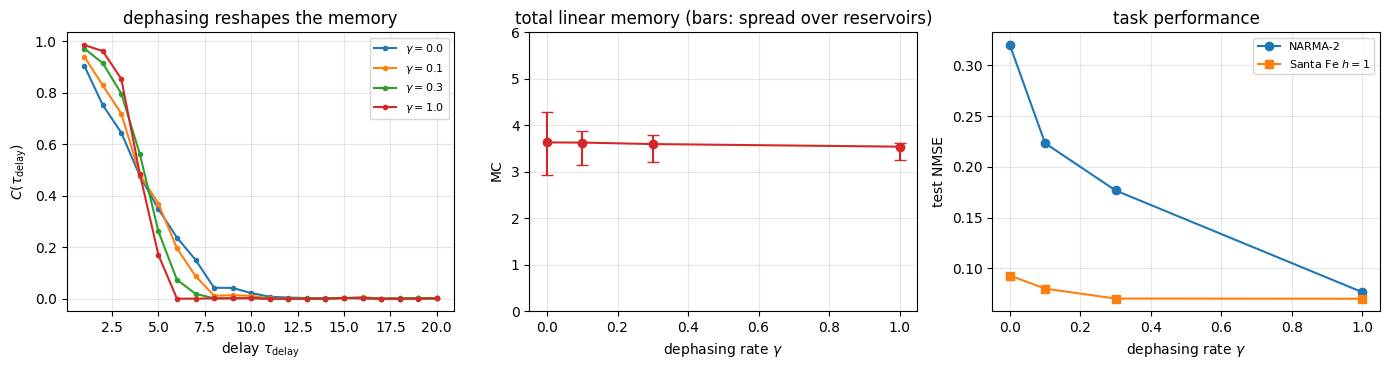


purity of the driven state: gamma = 0: 0.4335, gamma = 1: 0.0689 (maximally mixed would be 0.0625)


In [21]:
# ==============================================================================
# EXPERIMENT: dephasing and amplitude damping during the evolution
# ==============================================================================
GAMMAS = (0.0, 0.1, 0.3, 1.0)
deco = {}
for gamma in GAMMAS:
    jump = None if gamma == 0.0 else Z
    F_g, t_g = drive_ensemble(L_IN, N_RAILS, TAU, DT, u_iid, jump=jump, gamma=gamma)
    F_gs, _ = drive_ensemble(L_IN, N_RAILS, TAU, DT, u_sf, jump=jump, gamma=gamma)
    caps_g = np.array([memory_capacity(F_g[i], u_iid) for i in range(N_RES)])
    nn = np.array([evaluate(F_g[i], targets["NARMA-2"])[0] for i in range(N_RES)])
    sf = np.array([horizon_scores(F_gs[i], u_sf, 1)[0] for i in range(N_RES)])
    deco[gamma] = (caps_g, nn, sf)
    print(f"dephasing gamma = {gamma:4.2f}:  MC = {np.median(caps_g.sum(1)):.3f}, "
          f"C(1) = {np.median(caps_g[:, 0]):.3f}, C(3) = {np.median(caps_g[:, 2]):.3f}, "
          f"NARMA-2 {np.median(nn):.4f}, Santa Fe {np.median(sf):.4f}  ({2*t_g:.1f} s)")

F_ad, _ = drive_ensemble(L_IN, N_RAILS, TAU, DT, u_iid, jump=SM, gamma=0.3)
F_ads, _ = drive_ensemble(L_IN, N_RAILS, TAU, DT, u_sf, jump=SM, gamma=0.3)
caps_ad = np.array([memory_capacity(F_ad[i], u_iid) for i in range(N_RES)])
nn_ad = np.array([evaluate(F_ad[i], targets["NARMA-2"])[0] for i in range(N_RES)])
sf_ad = np.array([horizon_scores(F_ads[i], u_sf, 1)[0] for i in range(N_RES)])
print(f"amplitude damping gamma = 0.30:  MC = {np.median(caps_ad.sum(1)):.3f}, "
      f"NARMA-2 {np.median(nn_ad):.4f}, Santa Fe {np.median(sf_ad):.4f}")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
for gamma in GAMMAS:
    ax[0].plot(TAUS_MC, np.median(deco[gamma][0], axis=0), "o-", ms=3, label=rf"$\gamma={gamma}$")
ax[0].set_xlabel(r"delay $\tau_{\rm delay}$"); ax[0].set_ylabel(r"$C(\tau_{\rm delay})$")
ax[0].set_title("dephasing reshapes the memory"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
mc_g = [deco[g][0].sum(1) for g in GAMMAS]
ax[1].errorbar(GAMMAS, [np.median(m) for m in mc_g],
               yerr=[[np.median(m) - m.min() for m in mc_g], [m.max() - np.median(m) for m in mc_g]],
               fmt="o-", capsize=4, color="tab:red")
ax[1].set_ylim(0, 6)
ax[1].set_xlabel(r"dephasing rate $\gamma$"); ax[1].set_ylabel(r"$\mathrm{MC}$")
ax[1].set_title("total linear memory (bars: spread over reservoirs)"); ax[1].grid(alpha=0.3)
ax[2].plot(GAMMAS, [np.median(deco[g][1]) for g in GAMMAS], "o-", label="NARMA-2")
ax[2].plot(GAMMAS, [np.median(deco[g][2]) for g in GAMMAS], "s-", label="Santa Fe $h=1$")
ax[2].set_xlabel(r"dephasing rate $\gamma$"); ax[2].set_ylabel("test NMSE")
ax[2].set_title("task performance"); ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

rho_end_coh = driver_ml(Js_demo, hs_demo, input_windows(u_iid[:200], L_IN), to_dm(zero_state(N_QUBITS)))[0]
drv_deph = make_dm_driver(L_IN, N_RAILS, TAU, DT, jump=Z, gamma=1.0)
rho_end_deph = drv_deph(Js_demo, hs_demo, input_windows(u_iid[:200], L_IN), to_dm(zero_state(N_QUBITS)))[0]
print(f"\npurity of the driven state: gamma = 0: {float(purity(dm_matrix(rho_end_coh))):.4f}, "
      f"gamma = 1: {float(purity(dm_matrix(rho_end_deph))):.4f} "
      f"(maximally mixed would be {1/2**N_QUBITS:.4f})")

Dissipation helps, and the mechanism is visible in the first panel.

* **The total linear memory barely moves**: $\mathrm{MC}=3.63,\,3.63,\,3.60,\,3.54$ for $\gamma=0,0.1,0.3,1$ — a change
  of $2\,\%$ against a reservoir-to-reservoir spread of $\pm0.7$. The capacity sum rule is not a fragile quantum effect.
* **The profile changes completely.** Dephasing *sharpens* the short-time memory and truncates the long tail:
  $C(1)$ rises from $0.905$ to $0.985$ and $C(3)$ from $0.644$ to $0.853$, while everything beyond
  $\tau_{\rm delay}=6$ is wiped out. Coherent evolution spreads the trace of an input over many oscillating features,
  where a linear readout recovers it only partially; damping leaves a clean, monotonically decaying memory kernel.
* **The tasks follow the profile, not the total.** NARMA-2 improves from $0.320$ to $0.077$ and one-step laser
  prediction from $0.093$ to $0.070$. NARMA-2 needs an accurate memory of the last few steps and nothing beyond, which is
  exactly what dephasing delivers. At $\gamma=1$ the dissipative quantum reservoir is *better* than both classical
  baselines with the same number of features on NARMA-2 ($0.077$ against $0.152$ for the linear autoregression and
  $0.147$ for the echo-state network) — the one task in this notebook where it wins outright.
* Amplitude damping at $\gamma=0.3$ behaves like dephasing at the same rate ($\mathrm{MC}=3.73$, NARMA-2 $0.198$, laser
  $0.071$), so the effect is not specific to one channel.

The purity of the driven state falls from $0.43$ to $0.069$, against $1/2^N=0.0625$ for the maximally mixed state: at
$\gamma=1$ the reservoir is almost completely mixed and still computes better than the coherent one. Whatever this
machine uses, it is not the purity of its state.

> **Physics insight.** "Decoherence destroys the quantum advantage" is the wrong slogan for a reservoir. The task of a
> reservoir is to forget in a *useful* way, and a dissipative bath is a perfectly good forgetting mechanism — often a
> better-shaped one than unitary scrambling followed by an erasure. This is the numerical counterpart of the dissipative
> quantum reservoirs analysed by Chen and Nurdin and of the phase-diagram picture of Martínez-Peña *et al.*

## 11. Cost

The density-tensor driver keeps $4^N$ complex numbers and applies $O(V n_{\rm sub} G)$ gates per input step, each costing
$O(2^k4^N)$, plus $O((N+B)4^N)$ for the readout: **exponential in the number of qubits, linear in the length of the
series**. The trajectory driver keeps $2^N$ numbers per trajectory and costs $M$ times less memory per unit of accuracy
only if $M\ll 2^N$ — for small reservoirs the density tensor wins outright, which is why every experiment above used it.
The measurement below separates compilation (once per shape and per parameter set) from execution.

In [22]:
# ==============================================================================
# PERFORMANCE: cost per input step versus the number of qubits
# ==============================================================================
u_bench = np.random.default_rng(0).uniform(0.0, 1.0, 200)
print(f"{'N':>2s} {'p':>4s} {'compile (s)':>12s} {'run (s)':>9s} {'ms / input step':>16s} "
      f"{'ratio to N-1':>13s} {'rho memory':>12s}")
prev_t, t_dm_same_N = None, 0.0
for R_b in (2, 3, 4, 5, 6):
    Js_b, hs_b = reservoir_params(jax.random.PRNGKey(SEED_RES), 1, R_b, W=W_DIS)
    drv_b = make_dm_driver(1, R_b, TAU, DT)
    W_b, rho0_b = input_windows(u_bench, 1), to_dm(zero_state(R_b))
    t0 = time.time(); drv_b(Js_b, hs_b, W_b, rho0_b)[0].block_until_ready(); t_comp = time.time() - t0
    t0 = time.time(); drv_b(Js_b, hs_b, W_b, rho0_b)[0].block_until_ready(); t_run = time.time() - t0
    mem = 16 * 4 ** R_b
    print(f"{R_b:2d} {3*R_b + 3*(R_b-1):4d} {t_comp - t_run:12.2f} {t_run:9.3f} {1e3*t_run/len(u_bench):16.2f} "
          f"{'--' if prev_t is None else f'{t_run/prev_t:12.2f}'} "
          f"{mem/1024:9.1f} kB")
    prev_t = t_run
    if R_b == N_QUBITS:
        t_dm_same_N = t_run

M_bench = 256
keys_b = jax.random.split(jax.random.PRNGKey(0), M_bench)
t0 = time.time(); vmcwf(Js_demo, hs_demo, input_windows(u_bench, 1), zero_state(N_QUBITS), keys_b)[1].block_until_ready()
t_comp_mc = time.time() - t0
t0 = time.time(); vmcwf(Js_demo, hs_demo, input_windows(u_bench, 1), zero_state(N_QUBITS), keys_b)[1].block_until_ready()
t_run_mc = time.time() - t0
print(f"\nN = {N_QUBITS}: {M_bench} trajectories over {len(u_bench)} steps: compile {t_comp_mc - t_run_mc:.2f} s, "
      f"run {t_run_mc:.3f} s  ->  {1e3*t_run_mc/len(u_bench):.2f} ms per input step for the whole batch, "
      f"against {1e3*t_dm_same_N/len(u_bench):.2f} ms for the density tensor of the same N in the table above")

 N    p  compile (s)   run (s)  ms / input step  ratio to N-1   rho memory


 2    9         0.27     0.013             0.07 --       0.2 kB


 3   15         0.47     0.042             0.21         3.13       1.0 kB


 4   21         0.63     0.071             0.36         1.71       4.0 kB


 5   27         0.76     0.265             1.32         3.72      16.0 kB


 6   33         1.25     1.114             5.57         4.21      64.0 kB



N = 4: 256 trajectories over 200 steps: compile 0.92 s, run 0.514 s  ->  2.57 ms per input step for the whole batch, against 0.36 ms for the density tensor of the same N in the table above


The cost per input step grows by roughly the predicted factor of four per added qubit at the upper end of the table,
while the ratios at $N\le4$ are smaller and erratic: there the tensors have a few hundred entries and the time is set by
kernel dispatch, not by arithmetic. (Absolute timings on a shared machine move by tens of per cent between runs; the
$4^N$ scaling at large $N$ is the robust part, the small-$N$ ratios are not.) Extrapolating that factor, $N=8$ would need
a $1$ MB density tensor and of order $0.1$ s per input step — still workable for a thousand-step series — and $N=10$ a
$16$ MB tensor and a few seconds per step. That is the practical wall of the method, and it is a wall in $N$ alone: the
length of the time series enters linearly.

The trajectory driver is several times slower here for $256$ trajectories than the exact density tensor at $N=4$, which
is the expected verdict at small $N$: $M\cdot2^N$ beats $4^N$ only when $M\ll2^N$, and a useful $M$ is in the hundreds.
Trajectories become the only option when $4^N$ no longer fits in memory — and they are what an experiment does anyway.

> **JAX practice.** Compilation is $0.5$–$2.7$ s per configuration and is paid once per *shape and static argument set*.
> Because `Js` and `hs` are traced arrays, all six random reservoirs share one compiled program through `jax.vmap`, and a
> sweep over disorder costs one compilation instead of six. Changing $\tau$, $V$ or $\delta t$ changes the gate count and
> does force a recompilation — which is why the parameter sweeps above are organised as an outer Python loop over
> geometry and an inner `vmap` over reservoirs, and not the other way round.

## 12. Summary

**Key takeaways**

* Reservoir computing turns sequence learning into linear regression by refusing to train the dynamics. Everything then
  depends on two properties of the fixed dynamical system: it must forget its initial condition (echo state) and it must
  mix past inputs nonlinearly (separation). A driven many-body quantum system has both, and the erasure of the input
  qubits — a completely positive map, not the unitary evolution — is what supplies the forgetting.
* The quantum feature map is exactly multilinear in the vectors $(1,\cos\pi u_j,\sin\pi u_j)$ of the past inputs. That
  settles what the machine can represent: no powers of a single input beyond those two functions, but arbitrary products
  across different times, with coefficients fixed by the Hamiltonian.
* Two independent implementations of the same protocol — a density tensor with a Kraus reset and pure-state trajectories
  with measurement and reset — agree within the $1/\sqrt M$ statistical error, and both agree with a dense-matrix
  reference once the Trotter step is small enough.
* The measured linear memory capacity stays far below the number of readout features. The bound of Jaeger and of Dambre
  *et al.* counts *linearly independent* state variables, and the one- and two-body Pauli features of a small lattice are
  strongly redundant. Extra qubits, a shorter evolution time per step and temporal multiplexing all raise the capacity,
  each by much less than the growth of the feature count.
* The honest comparison at an *equal number of readout features* splits by task. On the chaotic laser series the
  quantum reservoir beats the linear autoregression by a factor of three (NMSE $0.093$ against $0.260$, and $0.024$ with
  four virtual nodes) and draws with a classical echo-state network of the same size ($0.097$). On NARMA it loses to
  both, because NARMA is dominated by a memory depth of five to ten steps that a four-qubit reservoir does not have and
  the baseline is handed for free. A classical network with a few hundred units, which costs microseconds to simulate,
  beats everything. At these sizes the interest of the quantum machine is what it teaches about driven open many-body
  dynamics, not a computational advantage.
* Finite measurement statistics degrade the readout gracefully, and the ridge parameter chosen on the validation block
  absorbs much of the damage; what does not degrade gracefully is the number of experiments, because a projective readout
  destroys the state and the whole input sequence has to be replayed for every readout time unless a rewinding or
  weak-measurement protocol is used.
* Dephasing during the evolution leaves the total linear memory within $2\,\%$ of its coherent value but redistributes
  it from a long weak tail into the first few delays ($C(1)$ from $0.91$ to $0.99$, $C(3)$ from $0.64$ to $0.85$). Every
  task that needs accurate short memory improves, and at $\gamma=1$ — where the state is almost maximally mixed — the
  reservoir beats both equal-size classical baselines on NARMA-2. Decoherence is not simply the enemy of a reservoir.

## 13. Exercises

1. (&#9733;) **Encoding.** Replace $R_y(\pi u)$ by the Fujii–Nakajima encoding
   $\sqrt{1-u}\,\vert0\rangle+\sqrt{u}\,\vert1\rangle$, for which $\langle Z\rangle$ is linear in $u$. Re-measure
   $C(\tau)$ and the NARMA-2 error. Does the linear-in-$u$ encoding help the linear task and hurt the nonlinear one?
2. (&#9733;) **Washout.** Set `WASHOUT = 0` and re-run the memory-capacity cell. Compare with the echo-state decay rates
   of Section 5 and explain how many steps of washout are actually needed at $\tau=0.125$ and at $\tau=2$.
3. (&#9733;&#9733;) **Readout set.** Drop the two-body correlators and keep only the $3N$ single-qubit features
   (`readout_ops` needs one line changed). How much capacity is lost, and how does the loss compare with the drop in the
   number of features? Then add the $\langle X_iY_j\rangle$-type mixed correlators and check whether the extra features
   are linearly independent of the ones already there (look at the singular values).
4. (&#9733;&#9733;) **The knob.** Map the plane $(\tau, h/J)$: for a grid of evolution times and field-to-coupling ratios,
   measure $\mathrm{MC}$ and the NARMA-2 error over several reservoirs. Where is the useful region, and does the best
   $\tau$ for memory coincide with the best $\tau$ for the nonlinear task?
5. (&#9733;&#9733;) **Extend the code: virtual nodes with unequal spacing.** The multiplexing in `make_dm_driver` reads
   out at equal intervals $\tau/V$. Implement logarithmic spacing and compare the capacity at the same $V$.
6. (&#9733;&#9733;&#9733;) **Free-running prediction.** Instead of predicting $u_{k+h}$ with a separate readout per
   horizon, feed the one-step prediction back as the next input and let the machine run autonomously. Measure how many
   steps the free-running series stays close to the laser data, and compare with the direct multi-step results of
   Section 8.
7. (&#9733;&#9733;&#9733;) **Physics: where does the memory live?** Track the entanglement entropy between the input rail
   and the memory rails during the drive, and the purity of the reservoir state, for $\tau=0.125$ and $\tau=2$. Relate
   what you find to the forgetting rates of Section 5 and to the capacity profiles of Section 6.
8. (&#9733;&#9733;&#9733;) **Trajectories as the readout.** Train the readout on features averaged over $M$ *trajectories*
   rather than on exact expectation values plus binomial noise, and compare the two noise models at equal $M$. Which one
   is optimistic, and why?

## 14. References

1. H. Jaeger, *The "echo state" approach to analysing and training recurrent neural networks*, GMD Report 148, German
   National Research Center for Information Technology (2001); reissued with an erratum note (2010) correcting
   Definition 3 and Proposition 1.
2. H. Jaeger, *Short term memory in echo state networks*, GMD Report 152, GMD Forschungszentrum Informationstechnik
   (2002). Proposition 2: for i.i.d. input and linear output units the memory capacity of an $N$-unit network obeys
   $\mathrm{MC}\le N$.
3. W. Maass, T. Natschläger and H. Markram, *Real-time computing without stable states: a new framework for neural
   computation based on perturbations*, Neural Computation **14**, 2531 (2002).
4. H. Jaeger and H. Haas, *Harnessing nonlinearity: predicting chaotic systems and saving energy in wireless
   communication*, Science **304**, 78 (2004).
5. M. Lukoševičius and H. Jaeger, *Reservoir computing approaches to recurrent neural network training*, Computer
   Science Review **3**, 127 (2009).
6. I. B. Yildiz, H. Jaeger and S. J. Kiebel, *Re-visiting the echo state property*, Neural Networks **35**, 1 (2012).
7. J. Dambre, D. Verstraeten, B. Schrauwen and S. Massar, *Information processing capacity of dynamical systems*,
   Scientific Reports **2**, 514 (2012).
8. K. Fujii and K. Nakajima, *Harnessing disordered-ensemble quantum dynamics for machine learning*, Physical Review
   Applied **8**, 024030 (2017).
9. K. Nakajima, K. Fujii, M. Negoro, K. Mitarai and M. Kitagawa, *Boosting computational power through spatial
   multiplexing in quantum reservoir computing*, Physical Review Applied **11**, 034021 (2019).
10. J. Chen and H. I. Nurdin, *Learning nonlinear input-output maps with dissipative quantum systems*, Quantum
    Information Processing **18**, 198 (2019).
11. J. Chen, H. I. Nurdin and N. Yamamoto, *Temporal information processing on noisy quantum computers*, Physical Review
    Applied **14**, 024065 (2020).
12. R. Martínez-Peña, G. L. Giorgi, J. Nokkala, M. C. Soriano and R. Zambrini, *Dynamical phase transitions in quantum
    reservoir computing*, Physical Review Letters **127**, 100502 (2021).
13. P. Mujal, R. Martínez-Peña, J. Nokkala, J. García-Beni, G. L. Giorgi, M. C. Soriano and R. Zambrini,
    *Opportunities in quantum reservoir computing and extreme learning machines*, Advanced Quantum Technologies **4**,
    2100027 (2021).
14. P. Mujal, R. Martínez-Peña, G. L. Giorgi, M. C. Soriano and R. Zambrini, *Time-series quantum reservoir computing
    with weak and projective measurements*, npj Quantum Information **9**, 16 (2023).
15. A. S. Weigend and N. A. Gershenfeld (editors), *Time Series Prediction: Forecasting the Future and Understanding the
    Past*, Santa Fe Institute Studies in the Sciences of Complexity, Proceedings Volume XV (Addison-Wesley, Reading,
    1994). Data set A was contributed by U. Hübner, with data collected by N. B. Abraham and C. O. Weiss; see also
    U. Hübner, N. B. Abraham and C. O. Weiss, *Dimensions and entropies of chaotic intensity pulsations in a
    single-mode far-infrared NH3 laser*, Physical Review A **40**, 6354 (1989).
16. A. F. Atiya and A. G. Parlos, *New results on recurrent network training: unifying the algorithms and accelerating
    convergence*, IEEE Transactions on Neural Networks **11**, 697 (2000). The tenth-order system of its Eq. (86) is
    what the reservoir-computing literature calls NARMA-10; the general NARMA-$n$ form of Eq. (7) is the generalisation
    used by A. Rodan and P. Tiňo, *Minimum complexity echo state network*, IEEE Transactions on Neural Networks **22**,
    131 (2011).

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/